---
title: "Case Study"
subtitle: "Cantilever beam"
date: today #25/04/2024
date-format: "D MMM, YYYY"
author: "Thyge Vinther Ludvigsen, s203591"
lang: en #en da  - sprog
#highlight-style: quarto_files/nord-dark-pro.theme # nord github-dark
highlight-style: nord # nord github-dark atom-one-dark
format:
  revealjs: 
    toc: true
    toc-title: "Overview"  # Customize the title of your TOC slide
    toc-depth: 1   # if 2 then it will include h2 and h3 in the TOC, if 1 then only h2
    # theme: dracula # dracula, dark, moon      Best white theme: serif, simple
    # theme: presentation_data/styles.scss
    theme: [dracula, presentation_data/styles.scss]
    slide-number: true
    incremental: false  # makes all lists incremental by default unless they have the .nonincremental class
    # chalkboard: 
    #   buttons: false
    navigation-mode: linear # this is also the default.
    preview-links: auto
    logo: presentation_data/img/DTU_logo.png
    css: presentation_data/styles.css
    footer: '[GitHub](https://github.com/Thygeminator/research-notebook)'
    # make all slides {.smaller .scrollable}
    smaller: true
    scrollable: true
    embed-resources: true
    # self-contained: true
    self-contained-math: true
    echo: false
    output: false
jupyter: python3

---

<!-- include-in-header:
  text: |
    <script src="https://cdn.plot.ly/plotly-3.0.1.min.js" charset="utf-8"></script> -->

::: {.content-hidden}
# Note for building the presentation

- [github example](https://github.com/quarto-dev/quarto-web/tree/main/docs/presentations/revealjs/demo)
    - [view of the slide show](https://quarto.org/docs/presentations/revealjs/demo/#/title-slide)

- [Quarto Documentation: Presentations](https://quarto.org/docs/presentations/)
    - note: that the revealjs — reveal.js (HTML) is the best options if i want to display heavy math
:::

::: {.content-hidden}
# Notes and ideas 

Physics → modal parameters → features → decisions

- Implicit likelihood vs explicit/exact likelihood  (Likelihoods are approximated or implicitly defined, e.g., through simulations, rather than explicitly formulated.)
  - have statistical models for the modal parameters, and then estimate the 

Evaluation:

- Bayesian risk
- ROC curves
- Overage [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix)



Stochastic Subspace Identification (SSI)   
Value of Information (VoI)
Bayesian model updating (BMU)

prior decision analysis 
preposterior decision analysis

approximate Bayesian computation by subset simulation (ABC-SS)
Markov chain Monte Carlo (MCMC)

:::

::: {.content-hidden}
## How to simplify the integration of my analysis? 

[Linear and Quadratic Discriminant Analysis](https://scikit-learn.org/stable/modules/lda_qda.html)

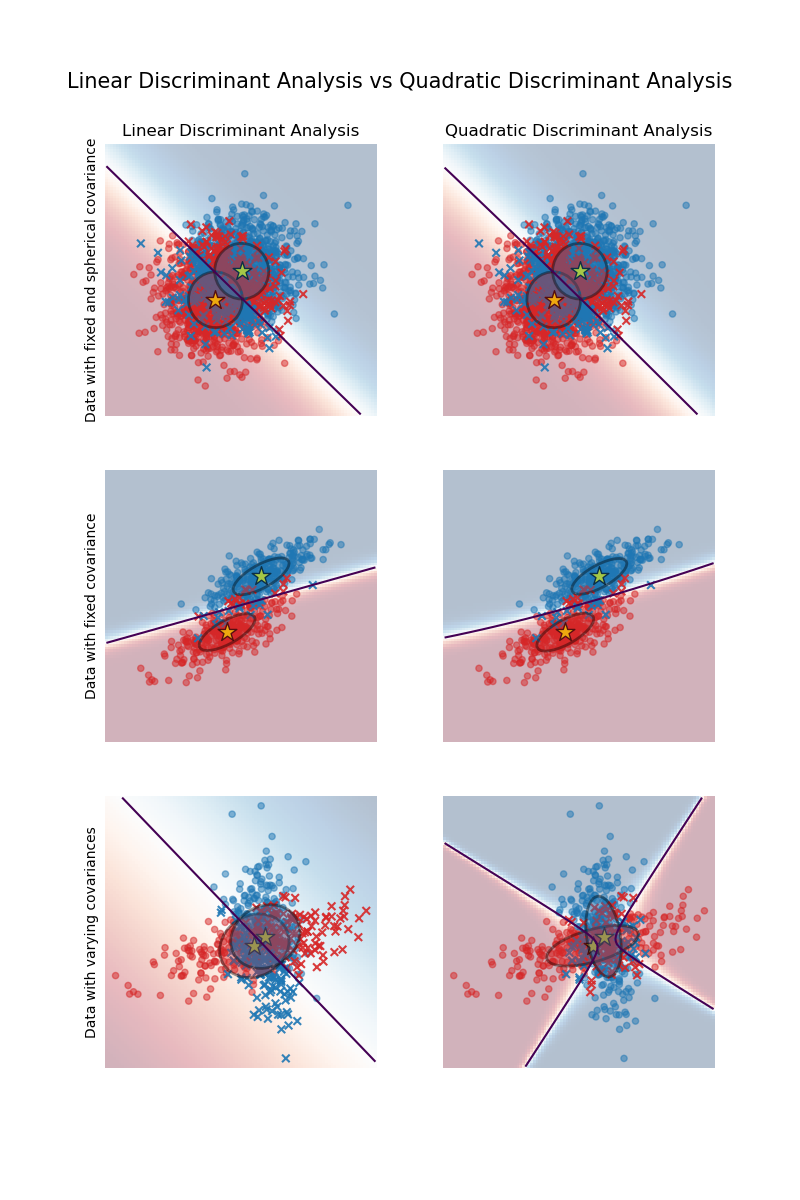{width=30%}


:::

In [1022]:
import numpy as np
import matplotlib.pyplot as plt

## Time Plan

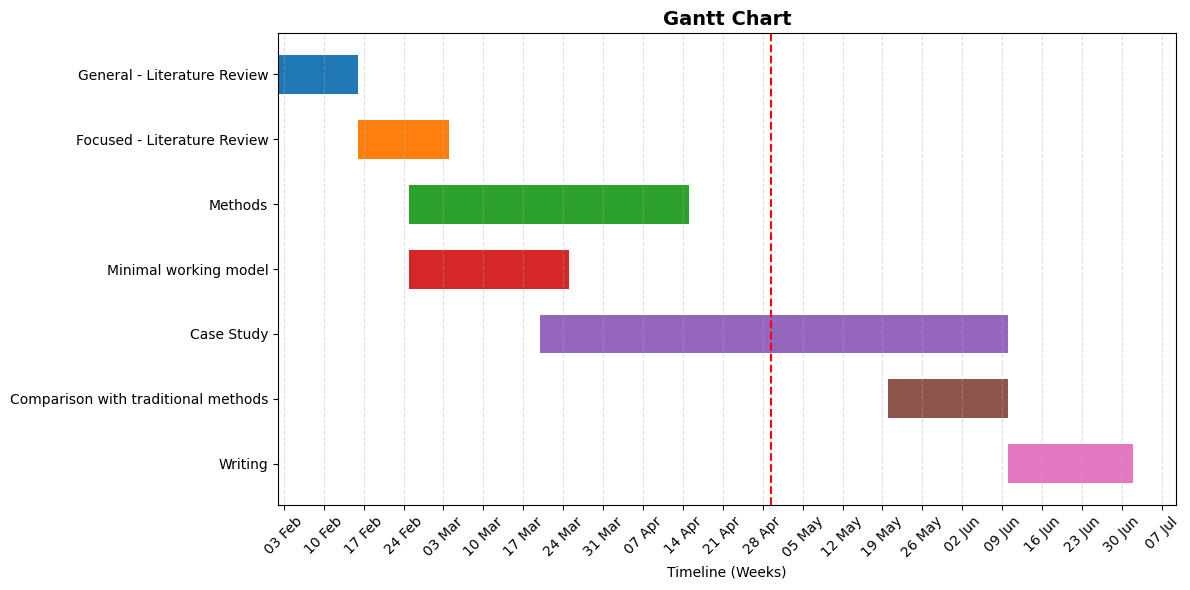

In [1023]:
#| echo: false
#| output: true
from python_code.gantt_chart import create_gantt_chart

create_gantt_chart()

# New Stochastic model

## Modal parameters

Stochastic modal parameters: 


$$
(\bar{\boldsymbol\omega}, \bar{\boldsymbol\phi}) \sim p(\boldsymbol\omega, \boldsymbol\phi \mid \theta)
$$

$$
(\bar{\boldsymbol\omega}, \bar{\boldsymbol\phi}) \sim g(\theta, e) + \epsilon(\theta, e)
$$

Where: 

- $g(\theta, e)$ is the deterministic part of the model, which depends on the structural state $\theta$ and the sensor configuration $e$.
- $\epsilon(\theta, e)  = \epsilon_0(\cdot) + ... + \epsilon_n(\cdot)$



## Sensor error model


Multivariate normal distribution:

$$
\epsilon_{\text{OMA}} \sim \mathcal{N}(0, \boldsymbol\Sigma_{OMA}(e)) 
$$

Diagonal covariance matrix: ^[[$\Sigma$](https://en.wikipedia.org/wiki/Multivariate_normal_distribution#Bivariate_case), [$\Sigma$](https://en.wikipedia.org/wiki/Covariance_matrix#Block_matrices)]

$$
\Sigma_{\text{OMA}}(e)=
\begin{bmatrix}
\Sigma_{\omega}(e) & 0 \\
0 & \Sigma_{\phi}(e)
\end{bmatrix}
$$

## Natural frequencies

::: panel-tabset
### Formulation

Frequency covariance Matrix:
$$
\Sigma_{\omega}(e) = \operatorname{diag}\!\left(
\operatorname{Var}(\hat{\omega}_1 \mid e),
\dots,
\operatorname{Var}(\hat{\omega}_m \mid e)
\right)
$$

Error approximation for frequencies:

$$
\boxed{
\operatorname{Var}(\hat{\omega}_i \mid e)
\;\approx\;
\frac{\sigma_\varepsilon^2}
{\;\|\mathbf S(e) \odot
 \phi_i\|_2^2}
}
$$

Where:

- $\sigma_\varepsilon = CV \cdot \mu_{\omega_i}$: sensor noise, given as sensor CV (coefficient of variation) multiplied by the mean value of the natural frequencies.
- $\|\mathbf S(e) \odot \phi_i\|_2^2$: is the modal observability,
   - $\| x \|_2$ is the L2 norm of the vector $x$, so the euclidean distance.
   - $\mathbf S(e)$ is the sensor configuration vector.
   - $\phi_i$ is the mode shape vector for the $i$-th mode, which describes the deformation pattern of the structure at that mode.
   - $\odot$ denotes the element-wise (Hadamard) product, which multiplies corresponding elements of the two vectors.


### Code illustration $\|\mathbf S(e) \odot \phi_i\|_2^{(\star)}$

$$
\|\mathbf S(e) \odot \phi_i\|_2 = \sqrt{\sum_{j=1}^{n} (S_j(e) \cdot \phi_{i,j})^2}
$$

$$
\sum_{j=1}^{n} (S_j(e) \cdot \phi_{i,j})^2 = (S_1(e) \cdot \phi_{i,1})^2 + (S_2(e) \cdot \phi_{i,2})^2 + ... + (S_n(e) \cdot \phi_{i,n})^2
$$

In [1024]:
#| echo: true
#| output: true
S = np.array([0, 1, 1])
phi = np.array([-1, 0.2, 0.5])
print(f"np.multiply(S, phi) = {np.multiply(S, phi)}")
print(f"np.linalg.norm(np.multiply(S, phi)) = {np.linalg.norm(np.multiply(S, phi))}") # element-wise multiplication and then take the L2 norm
print(f"Manual calculation: {np.sqrt(0.5**2 + 0.2**2)}") # manual calculation of the L2 norm

np.multiply(S, phi) = [-0.   0.2  0.5]
np.linalg.norm(np.multiply(S, phi)) = 0.5385164807134505
Manual calculation: 0.5385164807134505


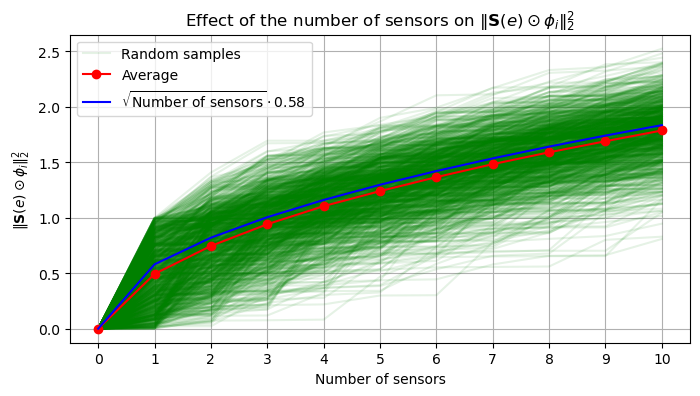

Mean values of |phi|: 0.4937138672223707
Number of samples: 1000


In [1025]:
#| output: true
number_of_sensors = 10
number_of_samples = 1000
number_of_sensors += 1 # to include the case with 0 sensors
y = np.zeros((number_of_samples, number_of_sensors)) 
phi = np.random.uniform(-1, 1, (number_of_samples, number_of_sensors))
phi = phi / np.max(np.abs(phi))
plt.figure(figsize=(8, 4))
for _ in range(number_of_samples):
    # print(f"phi: {np.round(phi, 2)}") 
    for i in range(number_of_sensors):
        S = np.zeros(number_of_sensors); S[:i] = 1
        y[_, i] += np.linalg.norm(np.multiply(S, phi[_]))
    
    plt.plot(range(number_of_sensors), y[_], alpha=0.1, color='green', label='Random samples' if _ == 0 else "")

plt.plot(range(number_of_sensors), np.mean(y, axis=0), marker='o', color='red', label='Average')

def fun(x):
    x = np.asarray(x)
    # out = np.zeros_like(x, dtype=float)
    # for i in range(len(x)):
    #     out[i] = np.sqrt(sum(0.58**2 for j in range(i)))
    out = np.sqrt(0.58**2 * x)
    return out

plt.plot(range(number_of_sensors), fun(range(number_of_sensors)), color='blue', label=r'$\sqrt{\text{Number of sensors}} \cdot 0.58$') 


plt.xlabel('Number of sensors')
plt.ylabel(r'$\|\mathbf{S}(e)\odot\phi_i\|_2^2$')
plt.title(r'Effect of the number of sensors on $\|\mathbf{S}(e)\odot\phi_i\|_2^2$')
# show all the numbers on the x-axis
plt.xticks(range(number_of_sensors))
plt.legend()
plt.grid()
plt.show()

print(f"Mean values of |phi|: {np.abs(phi).mean(axis=0).mean()}")
print(f"Number of samples: {number_of_samples}")


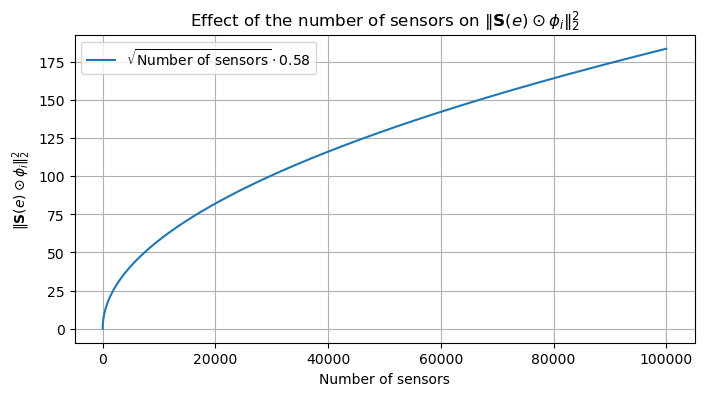

In [1026]:
plt.figure(figsize=(8, 4))
N = 10**5
plt.plot(np.sqrt(np.arange(N)) * 0.58, label=r'$\sqrt{\text{Number of sensors}} \cdot 0.58$')
plt.xlabel('Number of sensors')
plt.ylabel(r'$\|\mathbf{S}(e)\odot\phi_i\|_2^2$')
plt.title(r'Effect of the number of sensors on $\|\mathbf{S}(e)\odot\phi_i\|_2^2$')
# samme axises scale
# plt.gca().set_aspect('equal', adjustable='box')
# plt.xscale('log')
# plt.yscale('log', nonpositive='clip')
plt.legend()
plt.grid()
plt.show()

C:\Users\axiom\AppData\Local\Temp\ipykernel_23692\3122308532.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/(2*np.sqrt(np.arange(N)))* 0.58 , label=r'$\frac{1}{2\sqrt{\text{Number of sensors}}} \cdot 0.58$')


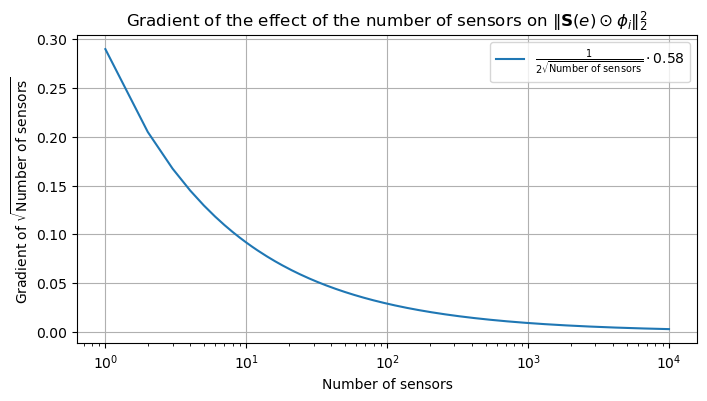

In [1027]:
# plot gradient 
plt.figure(figsize=(8, 4))
N = 10**4
plt.plot(1/(2*np.sqrt(np.arange(N)))* 0.58 , label=r'$\frac{1}{2\sqrt{\text{Number of sensors}}} \cdot 0.58$')
plt.xlabel('Number of sensors')
plt.ylabel(r'Gradient of $\sqrt{\text{Number of sensors}}$')
plt.title(r'Gradient of the effect of the number of sensors on $\|\mathbf{S}(e)\odot\phi_i\|_2^2$')
plt.legend()
plt.xscale('log')
plt.grid()
plt.show()

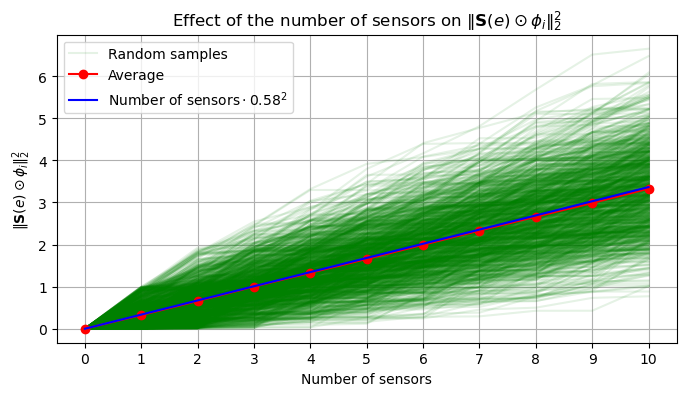

Mean values of |phi|: 0.49910643511437275
Number of samples: 1000


In [1028]:
#| output: true
number_of_sensors = 10
number_of_samples = 1000
number_of_sensors += 1 # to include the case with 0 sensors
y = np.zeros((number_of_samples, number_of_sensors)) 
phi = np.random.uniform(-1, 1, (number_of_samples, number_of_sensors))
phi = phi / np.max(np.abs(phi))
plt.figure(figsize=(8, 4))
for _ in range(number_of_samples):
    # print(f"phi: {np.round(phi, 2)}") 
    for i in range(number_of_sensors):
        S = np.zeros(number_of_sensors); S[:i] = 1
        y[_, i] += np.linalg.norm(np.multiply(S, phi[_]))**2
    
    plt.plot(range(number_of_sensors), y[_], alpha=0.1, color='green', label='Random samples' if _ == 0 else "")

plt.plot(range(number_of_sensors), np.mean(y, axis=0), marker='o', color='red', label='Average')

def fun(x):
    x = np.asarray(x)
    # out = np.zeros_like(x, dtype=float)
    # for i in range(len(x)):
    #     out[i] = np.sqrt(sum(0.58**2 for j in range(i)))**2
    out = 0.58**2 * x
    return out

plt.plot(range(number_of_sensors), fun(range(number_of_sensors)), color='blue', label=r'$\text{Number of sensors} \cdot 0.58^2$') 


plt.xlabel('Number of sensors')
plt.ylabel(r'$\|\mathbf{S}(e)\odot\phi_i\|_2^2$')
plt.title(r'Effect of the number of sensors on $\|\mathbf{S}(e)\odot\phi_i\|_2^2$')
# show all the numbers on the x-axis
plt.xticks(range(number_of_sensors))
plt.legend()
plt.grid()
plt.show()

print(f"Mean values of |phi|: {np.abs(phi).mean(axis=0).mean()}")
print(f"Number of samples: {number_of_samples}")


### Code illustration $\frac{1}{\|\mathbf S(e) \odot \phi_i\|_2^{(\star)}}$




C:\Users\axiom\AppData\Local\Temp\ipykernel_23692\1171957816.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  y[_, i] += 1/(np.linalg.norm(np.multiply(S, phi[_]))**2)


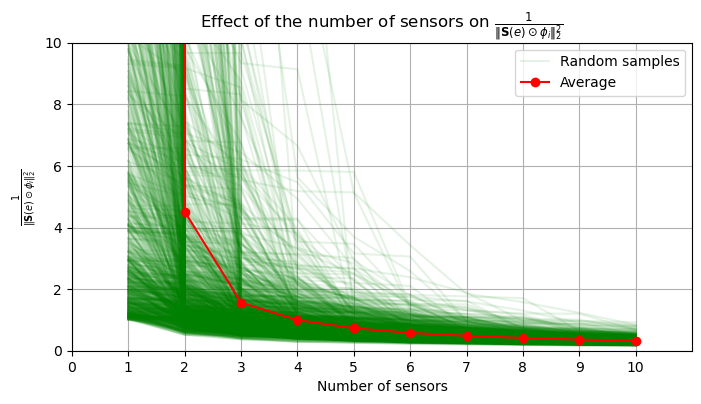

Mean values of |phi|: 0.5022195726544022
Number of samples: 1000


In [1029]:
#| output: true
number_of_sensors = 10
number_of_samples = 1000
number_of_sensors += 1 # to include the case with 0 sensors
y = np.zeros((number_of_samples, number_of_sensors)) 
phi = np.random.uniform(-1, 1, (number_of_samples, number_of_sensors))
phi = phi / np.max(np.abs(phi))
plt.figure(figsize=(8, 4))
for _ in range(number_of_samples):
    # print(f"phi: {np.round(phi, 2)}") 
    for i in range(number_of_sensors):
        S = np.zeros(number_of_sensors); S[:i] = 1
        y[_, i] += 1/(np.linalg.norm(np.multiply(S, phi[_]))**2)
    plt.plot(range(number_of_sensors), y[_], alpha=0.1, color='green', label='Random samples' if _ == 0 else "")
    # if y[_][1] < 0: # only plot the first 100 samples to avoid clutter
        #  plt.plot(range(number_of_sensors), y[_], alpha=0.1, color='green', label='Random samples' if _ == 0 else "")

plt.plot(range(number_of_sensors), np.mean(y, axis=0), marker='o', color='red', label='Average')

def fun(x):
    x = np.asarray(x)
    # out = np.zeros_like(x, dtype=float)
    # for i in range(len(x)):
    #     out[i] = np.sqrt(sum(0.58**2 for j in range(i)))**2
    out = 1/(0.58**2 * x)
    return out

# plt.plot(range(number_of_sensors), fun(range(number_of_sensors)), color='blue', label=r'$\text{Number of sensors} \cdot 0.58^2$') 


plt.xlabel('Number of sensors')
plt.ylabel(r'$\frac{1}{\|\mathbf{S}(e)\odot\phi_i\|_2^2}$')
plt.title(r'Effect of the number of sensors on $\frac{1}{\|\mathbf{S}(e)\odot\phi_i\|_2^2}$')
# show all the numbers on the x-axis
plt.xticks(range(number_of_sensors))
plt.legend()
plt.ylim(0,10)
plt.xlim(0, number_of_sensors)
plt.grid()
plt.show()

print(f"Mean values of |phi|: {np.abs(phi).mean(axis=0).mean()}")
print(f"Number of samples: {number_of_samples}")

C:\Users\axiom\AppData\Local\Temp\ipykernel_23692\3552534517.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  y[_, i] += 1/(np.linalg.norm(np.multiply(S, phi[_])))


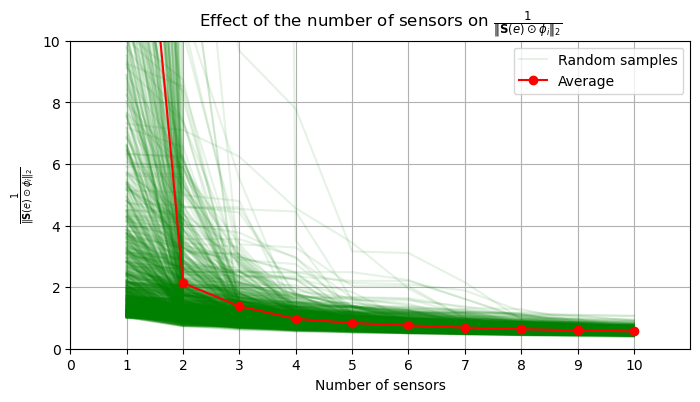

Mean values of |phi|: 0.503364421468163
Number of samples: 1000


In [1030]:
#| output: true
number_of_sensors = 10
number_of_samples = 1000
number_of_sensors += 1 # to include the case with 0 sensors
y = np.zeros((number_of_samples, number_of_sensors)) 
phi = np.random.uniform(-1, 1, (number_of_samples, number_of_sensors))
phi = phi / np.max(np.abs(phi))
plt.figure(figsize=(8, 4))
for _ in range(number_of_samples):
    # print(f"phi: {np.round(phi, 2)}") 
    for i in range(number_of_sensors):
        S = np.zeros(number_of_sensors); S[:i] = 1
        y[_, i] += 1/(np.linalg.norm(np.multiply(S, phi[_])))
    plt.plot(range(number_of_sensors), y[_], alpha=0.1, color='green', label='Random samples' if _ == 0 else "")
    # if y[_][1] < 0: # only plot the first 100 samples to avoid clutter
        #  plt.plot(range(number_of_sensors), y[_], alpha=0.1, color='green', label='Random samples' if _ == 0 else "")

plt.plot(range(number_of_sensors), np.mean(y, axis=0), marker='o', color='red', label='Average')

def fun(x):
    x = np.asarray(x)
    # out = np.zeros_like(x, dtype=float)
    # for i in range(len(x)):
    #     out[i] = np.sqrt(sum(0.58**2 for j in range(i)))**2
    out = 1/(0.58**2 * x)
    return out

# plt.plot(range(number_of_sensors), fun(range(number_of_sensors)), color='blue', label=r'$\text{Number of sensors} \cdot 0.58^2$') 


plt.xlabel('Number of sensors')
plt.ylabel(r'$\frac{1}{\|\mathbf{S}(e)\odot\phi_i\|_2}$')
plt.title(r'Effect of the number of sensors on $\frac{1}{\|\mathbf{S}(e)\odot\phi_i\|_2}$')
# show all the numbers on the x-axis
plt.xticks(range(number_of_sensors))
plt.legend()
plt.ylim(0,10)
plt.xlim(0, number_of_sensors)
plt.grid()
plt.show()

print(f"Mean values of |phi|: {np.abs(phi).mean(axis=0).mean()}")
print(f"Number of samples: {number_of_samples}")


:::
## Mode shapes

Mode shape covariance matrix: ^[[\operatorname{blkdiag}](), [Block matrix](https://en.wikipedia.org/wiki/Block_matrix)]
<!-- $$
\Sigma_{\phi}(e) = \operatorname{blkdiag}\!\left(
\operatorname{Var}(\hat{\phi}_1 \mid e),
\dots,
\operatorname{Var}(\hat{\phi}_m \mid e)
\right)
$$ -->

$$
\Sigma_{\phi}(e) = \operatorname{diag}\!\left(
\operatorname{Var}(\hat{\phi}_1 \mid e),
\dots,
\operatorname{Var}(\hat{\phi}_m \mid e)
\right)
$$

Error approximation for mode shapes:
$$
\boxed{
\operatorname{Var}(\hat{\phi}_i \mid e)
\;\approx\;
\frac{ \sigma_\varepsilon^2 }
{\;\|\mathbf S(e) \odot \phi_i\|_2^{2}}
}
$$

Where:

- $\sigma_\varepsilon = \sigma_\phi$: where $\sigma_\phi$ is the sensor noise for mode shapes I set it to be the same for all modes.
- $\|\mathbf S(e) \odot \phi_i\|_2$: is the modal observability.
   - $\| x \|_2$ is the L2 norm of the vector $x$, so the euclidean distance.
   - $\mathbf S(e)$ is the sensor configuration vector.
   - $\phi_i$ is the mode shape vector for the $i$-th mode, which describes the deformation pattern of the structure at that mode.
   - $\odot$ denotes the element-wise (Hadamard) product, which multiplies corresponding elements of the two vectors.

## Features

Feature vector:

$$
\boxed{
\mathbf y = h(\bar{\boldsymbol\phi}, \bar{\boldsymbol\omega})
}
$$

::: {.fragment .fade-in}
Where $h(\cdot)$ is an function that maps the modal parameters to the feature space.

- Natural frequencies, $\omega$
- Total Modal Assurance Criterion (TMAC)
  - $MAC(\phi_a,\phi_b)=\frac{|\phi_a^T\phi_b|^2}{(\phi_a^T\phi_a)(\phi_b^T\phi_b)}$
  - $TMAC(H_{\text{no damage}}, \bar{\boldsymbol\phi}) = \sum_{i=1}^{n} \frac{|\phi_{0,i}^T \bar{\phi}_i|^2}{(\phi_{0,i}^T \bar{\phi}_i)^2}$
- Modal Flexibility: $F = \sum_{i=1}^{n} \frac{\phi_i \phi_i^T}{\omega_i^2}$
:::

::: {.notes}
- Now do we not have features there do not lead to an explicit/exact likelihood
  - we need an Implicit likelihood or Approximate likelihood 
:::

## Problems

::: {.incremental}
- Features with nonlinear combinations of stochastic variables leads to implicit likelihoods. 
:::

# Code example - Stochastic model



## Goal of this code example

::: panel-tabset

### Goal

1. Setup an new stochastic model
2. generate modal parameters given an sensor configuration.
3. Compute the features for an given sensor configuration.

### how ?

Give:

- Modal parameters for all states, $\omega$ and $\phi$
- sensor coefficients of variation (CV)
- Sensor configuration vector, $S$
- Prior probabilities for the states, $p(\theta)$

Test: 

- Calculate the variance of the modal parameters given $S$ and CV
- Generate samples of modal parameters given $S$ and CV
- Compute the features for a given sensor configuration.

### Main code class

::: {.content-hidden}
# Bayesian risk class &starf;
:::

In [1031]:
#| echo: true
#| output: true
import numpy as np
from numpy.random import multivariate_normal

class BR:
  def __init__(self, omega_all, phi_all, CV_omega, sigma_phi, prior, N = 10**4, print_code = False):
    # all parameters for later use
    self.omega_all = omega_all
    self.phi_all = phi_all
    # No damage parameters
    self.omega_H0 = omega_all[0]
    self.phi_H0 = phi_all[0]
    # Damage parameters
    self.omega_H1 = omega_all[1:]
    self.phi_H1 = phi_all[1:] 
    
    # Coefficient of variation for omega and phi
    self.CV_omega = CV_omega
    self.sigma_phi = sigma_phi

    # number of Monte Carlo samples
    self.N = N
    
    # prior probabilities for theta
    self.prior = prior

    # print code
    self.print_code = print_code


  # def feature_vector(self, features_vector):

  #   return 

  # Statical parameters for the multivariate normal distribution 
  def covariance_matrix(self, S):
    # Sensor vector
    S = np.array(S)

    # Standard deviation
    sigma_omega = self.CV_omega * self.omega_H0 
    sigma_phi = self.sigma_phi * np.ones(self.phi_H0.shape[0]) 

    # modal observability
    mo = np.array([np.linalg.norm(np.multiply(S, phi_i)) for phi_i in self.phi_H0])

    # Variance Omega
    var_omega = sigma_omega**2 / (mo**2)

    # Variance Phi
    var_phi = sigma_phi**2 / (mo**2)

    # Diagonal covariance matrix
    # mu = np.concatenate([self.omega_H0, self.mask_and_normalize(self.phi_H0, S).flatten()])  # mean vector
    mu = self.mu_vector(self.omega_H0, self.phi_H0, S) # mean vector
    diagonal = np.concatenate([var_omega, np.repeat(var_phi, np.sum(S, dtype=int))])  # variances for omega and phi
    cov = np.diag(diagonal)  # covariance matrix
    
    # save for later use
    self.mu = mu
    self.cov = cov 
  
  def mu_vector(self, omega, phi, S):
    # Sensor vector
    S = np.array(S)
    # mean vector 
    mu = np.concatenate([omega, self.mask_and_normalize(phi, S).flatten()])  # mean vector
  
    return mu

  def mask_and_normalize(self,X, S):
    mask = S == 1

    # Step 1: apply mask on last axis
    filtered = X[..., mask]

    # Step 2: compute max along last axis
    max_vals = np.max(np.abs(filtered), axis=-1, keepdims=True)

    # Step 3: avoid division by zero
    max_vals[max_vals == 0] = 1

    # Step 4: normalize
    return filtered / max_vals


  def MCS_modal(self, S, prior_Importance = None):
    # S is the sensor vector
    S = np.array(S)

    # get covariance matrix and mean vector
    self.covariance_matrix(S)

    if prior_Importance is not None:
      # Imoportance sampling for structural states: theta ~ Q(theta) where Q is the importance distribution
      states = np.random.choice(range(len(self.prior)), size=self.N, p=prior_Importance)
      H_vec = (states > 0).astype(int)  # 0 if state == 0, else 1
      self.states = states
      self.H_vec = H_vec

    elif prior_Importance is None:
      # Generate all states and H labels at once: theta ~ P(theta)
      states = np.random.choice(range(len(self.prior)), size=self.N, p=self.prior)
      H_vec = (states > 0).astype(int)  # 0 if state == 0, else 1
      self.states = states
      self.H_vec = H_vec

    # generate errors for omega and phi
    # errors = np.random.multivariate_normal(mean=np.zeros(self.cov.shape[0]), cov=self.cov, size=self.N)

    # model properties 
    # lambda_star = np.random.multivariate_normal(mean=self.mu, cov=self.cov, size=self.N)
    lambda_star = np.random.multivariate_normal(mean=np.zeros(self.cov.shape[0]), cov=self.cov, size=self.N)
    lambda_star[:, :len(self.omega_H0)] += self.omega_all[states]
    lambda_star[:, len(self.omega_H0):] += self.mask_and_normalize(self.phi_all[states], S).reshape(self.N, -1)
    self.lambda_star = lambda_star

    # extract omega and phi from lambda_star
    omega_bar = lambda_star[:, :self.omega_H0.shape[0]]
    # phi_bar = lambda_star[:, self.omega_H0.shape[0]:]
    phi_bar = lambda_star[:, self.omega_H0.shape[0]:].reshape(self.N, self.phi_H0.shape[0], np.sum(S, dtype=int))
    self.phi_no_norm = phi_bar.copy() # save the non-normalized phi for later use
    # normize phi_bar by  by the maximum absolute value across all samples for each mode
    # normalize each mode-shape vector per sample (along the last axis)
    max_abs = np.max(np.abs(phi_bar), axis=2, keepdims=True)  # shape: (N, N_phi, 1)
    phi_bar = phi_bar / np.where(max_abs == 0, 1, max_abs)
    # phi_bar = self.mask_and_normalize(phi_bar, S)

    self.omega_bar = omega_bar
    self.phi_bar = phi_bar
    

  def MAC(self, phi1, phi2):
    # Compute the Modal Assurance Criterion (MAC) between two mode shapes
    numerator = np.abs(np.dot(phi1, phi2))**2
    denominator = np.dot(phi1, phi1) * np.dot(phi2, phi2)
    return numerator / denominator if denominator != 0 else 0

  def TMAC(self, phi_theta_1, phi_theta_2):
    N_samples = phi_theta_1.shape[0]
    TMAC_matrix = np.zeros((N_samples, N_samples))
    for i in range(N_samples):
        for j in range(N_samples):
            TMAC_matrix[i, j] = self.MAC(phi_theta_1[i], phi_theta_2[j])

    # sum of diagonal of the MAC 
    self.print2("TMAC matrix:\n", TMAC_matrix)  
    TMAC = np.sum(np.diag(TMAC_matrix)) / (N_samples)
    return TMAC
  
  # Modal Flexibility (MF)
  def MF(self, phi_vec, omega_vec):
    # Compute the Modal Flexibility (MF) for a given mode shape and natural frequency
    return sum(np.diag(np.abs(np.dot(phi_vec, phi_vec.T) / (omega_vec**2))))

  def print2(self, *args):
    if self.print_code:
        print(*args)
    

:::

## Code - Setup

<!-- here is the code for setting up the stochastic model, and generating samples of modal parameters given a sensor configuration. -->

::: {.notes}
- show mode shapes and that they are normilized

:::

In [1032]:
#| echo: true
#| output: true
#| code-line-numbers: "|3-9|11-13|15-16|18-19|21-22|24-28|"
np.random.seed(32)

# frequencyes and mode shapes
omega_all = np.array([[1, 6.72223044],    # H0, theta_0
                      [1.2, 8.72223044],  # H1, theta_1
                      [1.6, 10.8]])          # H1, theta_2
phi_all = np.array([[[0.4, 0.5, 1], [-0.3, -1, .5]],   # H0, theta_0
                    [[0.2, 0.2, 1], [-0.5, -1, .5]],   # H1, theta_1
                    [[-0.1, 0.1, 1], [-0.9, -1, .5]]]) # H1, theta_2

# Coefficient of variation (CV)
CV_omega = 0.1
sigma_phi = 0.2

# Prior probabilities for the states (theta)
prior = np.array([0.5, 0.4, 0.1])

# Number of Samples 
N = 10**4

# Instantiate the BR class
BRinf = BR(omega_all, phi_all, CV_omega, sigma_phi, prior, N)

# Sensor configuration
S = np.array([1, 1, 1])

# Generate modal parameters given the sensor configuration
BRinf.MCS_modal(S)

"""Simple results"""
print("Sampled states (theta):", BRinf.states)
print(f"#θ_0 = {sum(BRinf.states == 0)}, fraction = {sum(BRinf.states == 0) / BRinf.N:.2f}")
print(f"#θ_1 = {sum(BRinf.states == 1)}, fraction = {sum(BRinf.states == 1) / BRinf.N:.2f}")
print(f"#θ_2 = {sum(BRinf.states == 2)}, fraction = {sum(BRinf.states == 2) / BRinf.N:.2f}")

print("\nSampled modal parameters")
print("-" * 40)
print("Frequencies:")
print(np.round(BRinf.omega_bar[0], 4))

print("\nMode shapes:")
print(np.round(BRinf.phi_bar[0], 4))

Sampled states (theta): [1 0 1 ... 1 0 1]
#θ_0 = 4915, fraction = 0.49
#θ_1 = 4071, fraction = 0.41
#θ_2 = 1014, fraction = 0.10

Sampled modal parameters
----------------------------------------
Frequencies:
[1.2598 8.996 ]

Mode shapes:
[[ 0.3688  0.1529  1.    ]
 [-0.4113 -1.      0.3475]]


In [1033]:
np.dot(BRinf.phi_bar[0], BRinf.phi_bar[0].T)

array([[1.15938662, 0.04292512],
       [0.04292512, 1.2899451 ]])

In [1034]:
np.dot(BRinf.phi_bar[0][1], BRinf.phi_bar[0][1].T), BRinf.phi_bar[0][1]

(np.float64(1.2899451037910952),
 array([-0.41130016, -1.        ,  0.34753026]))

In [1035]:
sum(np.diag(np.abs(np.dot(BRinf.phi_bar[0], BRinf.phi_bar[0].T) / (BRinf.omega_bar[0]**2)))), BRinf.MF(BRinf.phi_bar[0], BRinf.omega_bar[0])

(np.float64(0.74648476133149), np.float64(0.74648476133149))

## Plot - Omega

::: {.notes}
- it can esaly be seen that there are 2 damage senarios in H_1
:::

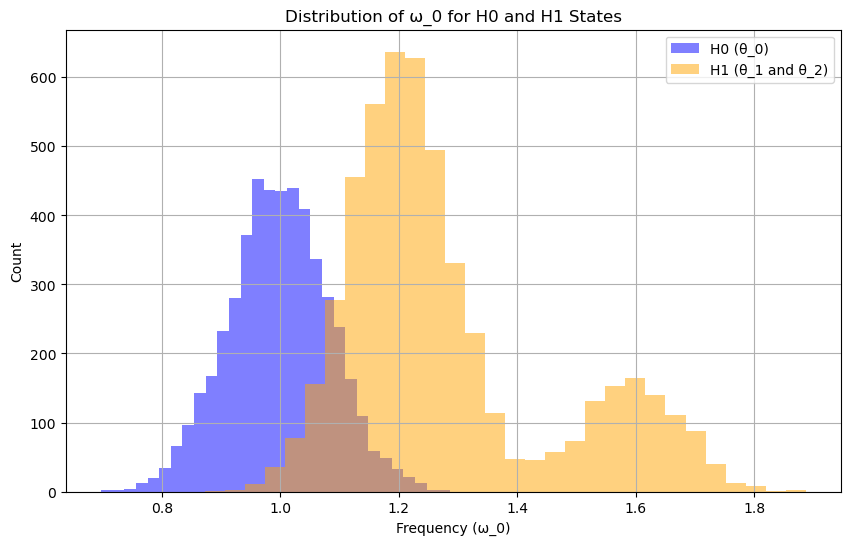

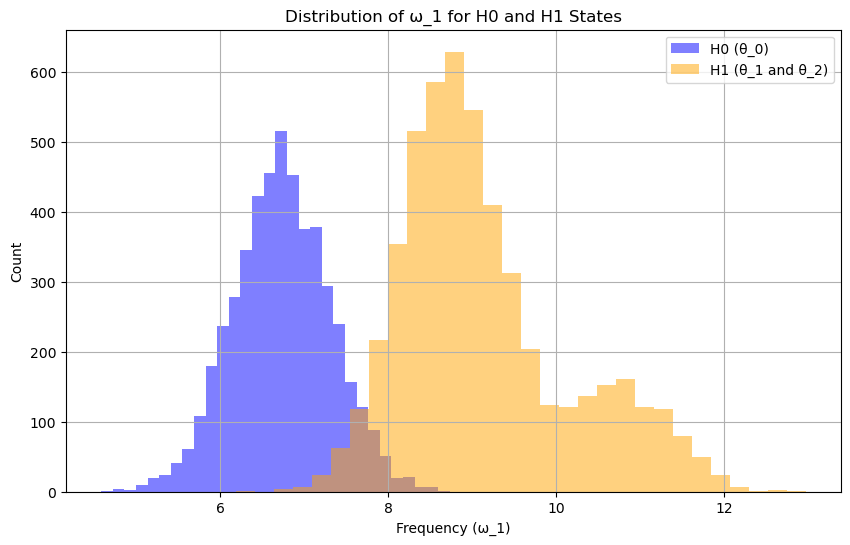

In [1036]:
#| output: true

# plot omega_0 for the H0 and H1 states
plt.figure(figsize=(10, 6))
plt.hist(BRinf.omega_bar[BRinf.H_vec == 0][:, 0], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist(BRinf.omega_bar[BRinf.H_vec == 1][:, 0], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
plt.xlabel('Frequency (ω_0)')
plt.ylabel('Count')
plt.title('Distribution of ω_0 for H0 and H1 States')
plt.legend()
plt.grid()
plt.show()

# plot omega_1 for the H0 and H1 states
plt.figure(figsize=(10, 6))
plt.hist(BRinf.omega_bar[BRinf.H_vec == 0][:, 1], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist(BRinf.omega_bar[BRinf.H_vec == 1][:, 1], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
plt.xlabel('Frequency (ω_1)')
plt.ylabel('Count')
plt.title('Distribution of ω_1 for H0 and H1 States')
plt.legend()
plt.grid()
plt.show()

## Plot - Mode shapes 1

::: {.notes}
- see the distibution of the mode shapes, and there normilization
:::

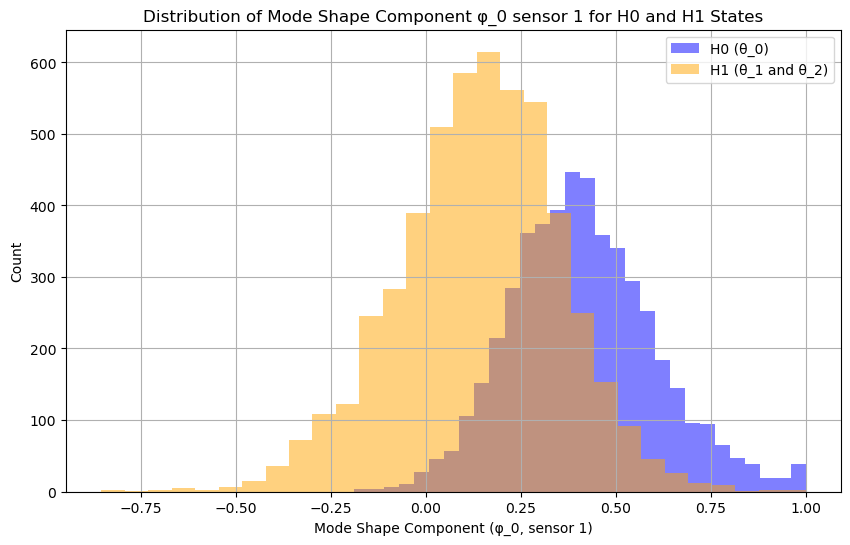

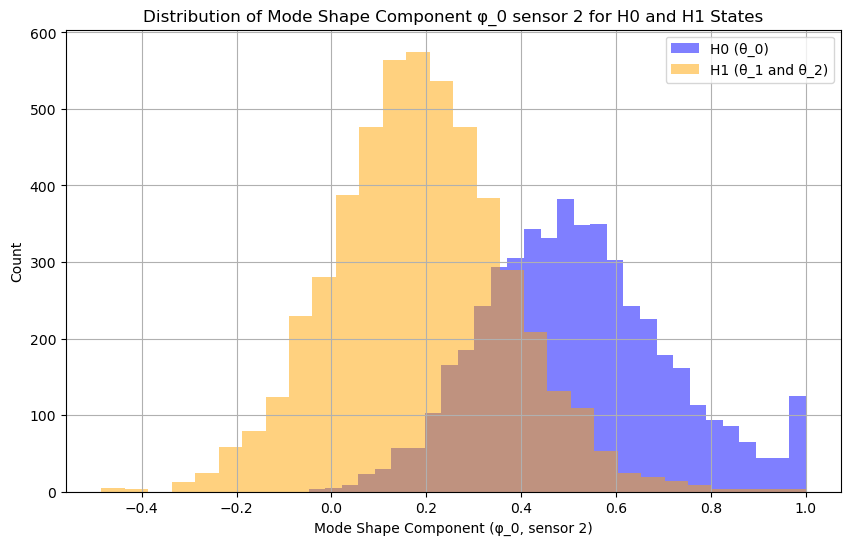

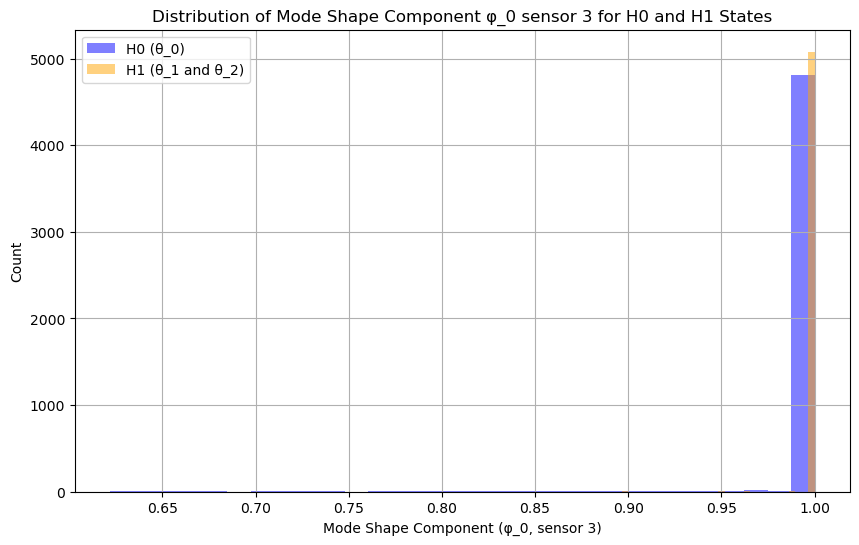

In [1037]:
#| output: true

# plot mode shapes 0 for the H0 and H1 states sensor 1
plt.figure(figsize=(10, 6))
plt.hist(BRinf.phi_bar[BRinf.H_vec == 0][:, 0, 0], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist(BRinf.phi_bar[BRinf.H_vec == 1][:, 0, 0], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
plt.xlabel('Mode Shape Component (φ_0, sensor 1)')
plt.ylabel('Count')
plt.title('Distribution of Mode Shape Component φ_0 sensor 1 for H0 and H1 States')
plt.legend()
plt.grid()
plt.show()

# test if the is more then one sensor
if BRinf.phi_bar.shape[2] > 1:
    # plot mode shapes 0 for the H0 and H1 states sensor 2
    plt.figure(figsize=(10, 6))
    plt.hist(BRinf.phi_bar[BRinf.H_vec == 0][:, 0, 1], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
    plt.hist(BRinf.phi_bar[BRinf.H_vec == 1][:, 0, 1], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
    plt.xlabel('Mode Shape Component (φ_0, sensor 2)')
    plt.ylabel('Count')
    plt.title('Distribution of Mode Shape Component φ_0 sensor 2 for H0 and H1 States')
    plt.legend()
    plt.grid()
    plt.show()

if BRinf.phi_bar.shape[2] > 2:
    # plot mode shapes 0 for the H0 and H1 states sensor 3
    plt.figure(figsize=(10, 6))
    plt.hist(BRinf.phi_bar[BRinf.H_vec == 0][:, 0, 2], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
    plt.hist(BRinf.phi_bar[BRinf.H_vec == 1][:, 0, 2], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
    plt.xlabel('Mode Shape Component (φ_0, sensor 3)')
    plt.ylabel('Count')
    plt.title('Distribution of Mode Shape Component φ_0 sensor 3 for H0 and H1 States')
    plt.legend()
    plt.grid()
    plt.show()



## Plot - MAC + TMAC

::: {.notes}
- all of this is an comparison of sample 1 whit undamage cass?
- I have in cluded some MAC and TMAC functions
:::

In [1038]:
"MAC with mode 1 no damage and whit damage"
i = 0
print(f"MAC with mode {i+1} no damage and whit damage")
print(f"Mode shape from H0 (no damage):", BRinf.mask_and_normalize(BRinf.phi_H0, S)[0])
print(f"Mode shape first random sample:", BRinf.phi_bar[i, 0]) 

BRinf.print_code = True

mac_00 = BRinf.MAC(BRinf.mask_and_normalize(BRinf.phi_H0, S)[0], BRinf.phi_bar[i, 0])
print(f"\n\nMAC for mode {i+1}:", mac_00, "\n")

"TMAC with mode 1 no damage and whit damage"
tmac_00 = BRinf.TMAC(BRinf.mask_and_normalize(BRinf.phi_H0, S), BRinf.phi_bar[i])
print(f"TMAC for mode {i+1} (no damage vs damage):", tmac_00)



print(f"\nStructural state of the first random sample:", "H0 (no damage)" if BRinf.H_vec[0] == 0 else "H1 (damage)")
BRinf.print_code = False

MAC with mode 1 no damage and whit damage
Mode shape from H0 (no damage): [0.4 0.5 1. ]
Mode shape first random sample: [0.36878263 0.15292478 1.        ]


MAC for mode 1: 0.916427290142628 

TMAC matrix:
 [[0.91642729 0.05524592]
 [0.03598408 0.97343698]]
TMAC for mode 1 (no damage vs damage): 0.9449321349149749

Structural state of the first random sample: H1 (damage)


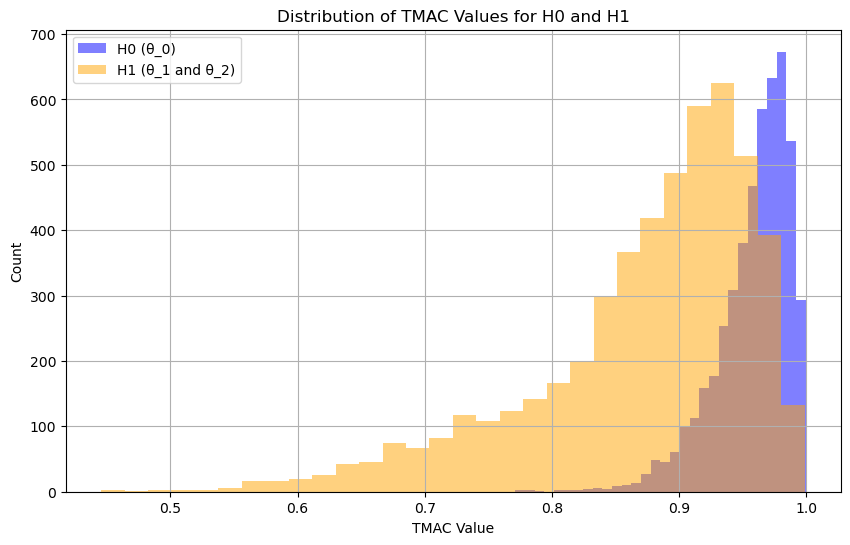

In [1039]:
#| output: true
plt.figure(figsize=(10, 6))
plt.title('Distribution of TMAC Values for H0 and H1')
plt.hist([ BRinf.TMAC(BRinf.mask_and_normalize(BRinf.phi_H0, S), v) for v in BRinf.phi_bar[BRinf.H_vec == 0] ], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist([ BRinf.TMAC(BRinf.mask_and_normalize(BRinf.phi_H0, S), v) for v in BRinf.phi_bar[BRinf.H_vec == 1] ], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
plt.xlabel('TMAC Value')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.show()

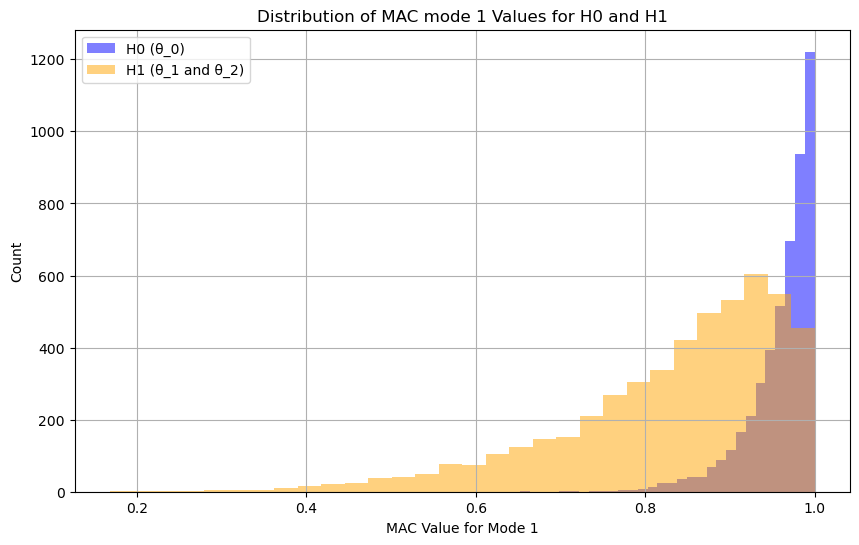

In [1040]:
#| output: true
plt.figure(figsize=(10, 6))
plt.title('Distribution of MAC mode 1 Values for H0 and H1')
plt.hist([ BRinf.MAC(BRinf.mask_and_normalize(BRinf.phi_H0, S)[0], v) for v in BRinf.phi_bar[BRinf.H_vec == 0][:, 0] ], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist([ BRinf.MAC(BRinf.mask_and_normalize(BRinf.phi_H0, S)[0], v) for v in BRinf.phi_bar[BRinf.H_vec == 1][:, 0] ], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
plt.xlabel('MAC Value for Mode 1')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.show()


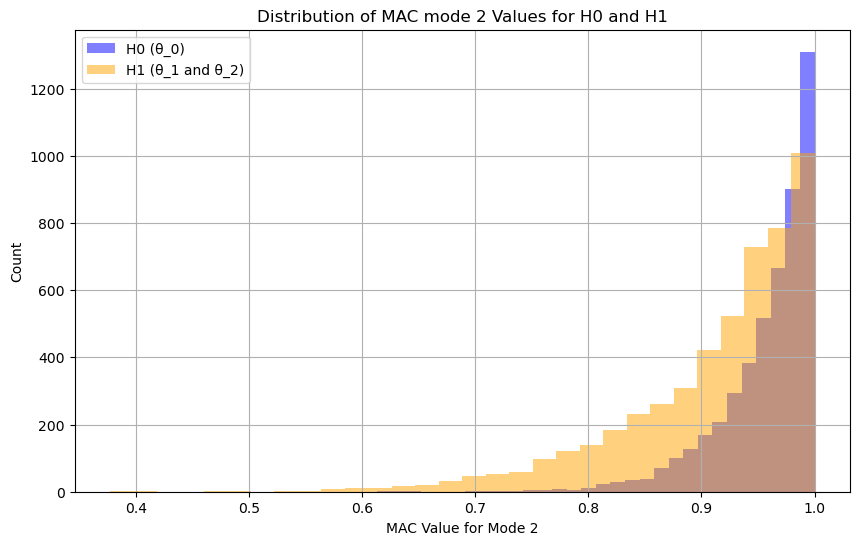

In [1041]:
#| output: true
plt.figure(figsize=(10, 6))
plt.title('Distribution of MAC mode 2 Values for H0 and H1')
plt.hist([ BRinf.MAC(BRinf.mask_and_normalize(BRinf.phi_H0, S)[1], v) for v in BRinf.phi_bar[BRinf.H_vec == 0][:, 1] ], bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist([ BRinf.MAC(BRinf.mask_and_normalize(BRinf.phi_H0, S)[1], v) for v in BRinf.phi_bar[BRinf.H_vec == 1][:, 1] ], bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')
plt.xlabel('MAC Value for Mode 2')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.show()

## Plot - Modal Flexibility (MF)

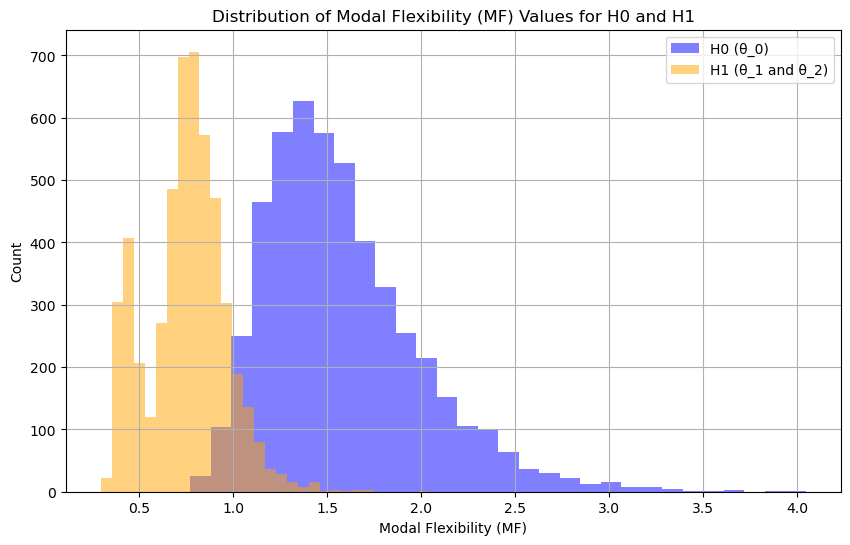

In [1042]:
#| output: true
plt.figure(figsize=(10, 6))
plt.title('Distribution of Modal Flexibility (MF) Values for H0 and H1')

h0_mask = BRinf.H_vec == 0
h1_mask = BRinf.H_vec == 1

mf_h0 = [BRinf.MF(phi, omega) for phi, omega in zip(BRinf.phi_bar[h0_mask], BRinf.omega_bar[h0_mask])]
mf_h1 = [BRinf.MF(phi, omega) for phi, omega in zip(BRinf.phi_bar[h1_mask], BRinf.omega_bar[h1_mask])]

plt.hist(mf_h0, bins=30, alpha=0.5, label='H0 (θ_0)', color='blue')
plt.hist(mf_h1, bins=30, alpha=0.5, label='H1 (θ_1 and θ_2)', color='orange')

plt.xlabel('Modal Flexibility (MF)')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.show()

::: {.content-hidden}
# Questions

## Likelihood double use 

Workflow MCS for Bayesian risk:

0. ... 
1. for an sensor configuration $S$, calculate the staticial parameters for the likelihood function. 
2. sample structural states, $\theta$, from the prior distribution, $p(\theta)$.
3. sample modal parameters, $(\bar{\boldsymbol\omega}, \bar{\boldsymbol\phi})$, from the likelihood function, $p(\bar{\boldsymbol\omega}, \bar{\boldsymbol\phi} \mid \theta, S)$.
4. compute the likelihood of the modal properties for being in state $H_0$ or $H_1$
    - But I use the error function for the sensor configuration as if it was perfectly known?
5. ...

::: {.callout-caution title="Question ?"}
In this setup of the model, do I assume **perfect knowledge of the statistical error parameters** for a given sensor configuration when I calculate the likelihood of the modal properties for being in state $H_0$ or $H_1$?

- Is this a defensible approach, or is it problematic for the validity of the model?
:::

::: {.notes}
- What is this error called? = Ignoring uncertainty in the nuisance parameters = "underpropagation of uncertainty" or "ignoring hyperparameter uncertainty"
- Fix use an hierarchical model, where the error parameters are also treated as random variables with their own prior distributions.
:::

## likelihood: explicit to implicit

When we **introduce the stochasticity in the model parameters**, and **not in the features**, do we end up with a problem for the **likelihood function**? 

- We have nonlinear combinations of normaly distributed variables, which leads to non-normal distributions of the features
- this means that we can not use an multivariate normal distribution as likelihood function for the features, which is what we have been doing in the past.

::: {.callout-caution title="Question ?"}
What to do now? 
:::  



::: {.callout-tip title="Solution 1: Explicit likelihood"}
- Use some of the modal properties as features
- select thos whit the biggets difference between the damage and undamage state.
:::

::: {.callout-tip title="Solution 2: Implicit likelihood"}
General work flow:

- Given an sensor configuration
- Sample the modal parameters
- Compute the features for each sample
- Build an empirical distribution of the features for each state, which can be used as an implicit likelihood function for the features.  (&starf;) ($\Large \star$)
- Usse the Implicit likelihood for the features in the Bayesian decision analysis.

Idea: build an surrogate model that links variance in OMA error to likelihood of the features. (Fast computation)
:::


::: {.callout-tip title="Solution 3: No likelihood"}
Idea:  

Inttroduce a decision rule there dos not use the likelihood function, but instead directly uses the features to make decisions.

Example: 

- Train an supervised machine learning (ML) algorithm to classify the structural states based on the features.
- Use Monte Carlo simulations to estimate the risk (Bayesian risk) for this decision rule.

Problems: 

- What to use as training data for the ML algorithm?
- what algorithm to use?
    - Simpe start: use Tree-based methods se Cap 9 in [Introduction to Machine Learning and Data Mining](https://02465material.pages.compute.dtu.dk/02465public/_assets/02450Book.pdf) page 169. 

:::



::: {.notes}
- implicit likelihood: is defined through simulations, rather than explicitly formulated.
- explicit likelihood: is explicitly formulated based on a mathematical model of the data-generating process, allowing for direct computation of probabilities.



Maby relevant papper: [Non-Linear Transformations of Gaussians and Gaussian-Mixtures with implications on Estimation and Information Theory](https://arxiv.org/pdf/1111.5950)
:::

## Implicite likelihoode

::: {.callout-caution title="Question ?"}
Have you bild an implicit likelihood function befor? and do you have any tips / resources for how to do it?
:::  

::: {.callout-caution title="Problems"}
- what data to use for building the implicit likelihood?
- how to build the implicit likelihood for an vector of features? 
- Iders for building a surrogate mode there links the variance in the OMA error for an given sensor configuration to the likelihood of the features? (Fast computation)

Note: all this is dependent on the structure there is evluated.
:::  

## No likelihood

Use supervised machine learning (ML) to directly classify the structural states $H_0$ and $H_1$ based on the features.

::: {.callout-caution title="Question ?"}
- what data to use for training the ML algorithm? (&starf; &starf; &starf;)
    - Use data for difrent sensor configurations, but dont lable the configurations ?
    - set up bound for the staticial paramters for the OMA error chose chose different noise levels for the training data? 
    - generate data independent of the prior distributions? 
- Do you think that Tree-based classification methods would be a good starting point for this problem?

Note: all this is dependent on the structure there is evluated.
:::  

:::

# case study Overview

## Goal of this Cass study

::: {.incremental}
- Setup an new stochastic model
- Evaluate the Bayes risk whit the new stochastic model
- Try out new decision rules
- Implement importance sampling in MCS
:::

## Chosen Features

Modal properties: 

- x first natural frequencies
- x first mode shapes


Features: 

- natural frequencies
- Total Modal Assurance Criterion (TMAC)
  - $MAC(\phi_a,\phi_b)=\frac{|\phi_a^T\phi_b|^2}{(\phi_a^T\phi_a)(\phi_b^T\phi_b)}$
  - with no damage as reference $H_0$
- Modal Flexibility
  - $F = \sum_{i=1}^{n} \frac{\phi_i \phi_i^T}{\omega_i^2}$




## Evaluation of the Bayes risk

Numarical integration: 

- Monte Carlo simulation (MCS)
- MCS with importance sampling 

Decision rules:

- Explicit likelihood for Modal properties (no use of features)
    - Maximum a posteriori (MAP) decision rule $\delta(y) = \arg\max_{a} p(H \mid y)$
    <!-- - Maximum expected utility (MEU) decision rule $\delta(x) = \arg\max_{a} \int p(\theta \mid x) u(a, \theta) d\theta$ -->
- Supervised Machine learning (ML) classification based on the features (no use of likelihood)
    - Logistic regression
    - Tree-based methods

## Prior distibution

::: {.notes}
I have chosen to use uniformed priors for the damage states? 
:::

In [1043]:
#| echo: fallse
#| output: true
H_1 = 0.01
H_0 = 1-H_1

# uninformed prior
N_prior = 2**4
prior_H = np.array([H_0, H_1])
prior_theta = np.concatenate(([H_0], np.repeat(H_1 / (N_prior - 1), N_prior - 1)))

print(f"Prior probabilities for H: {prior_H}")
print(f"\nPrior probabilities for θ: {np.round(prior_theta, 4)}")

Prior probabilities for H: [0.99 0.01]

Prior probabilities for θ: [9.9e-01 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04
 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04 7.0e-04]


## Cost function

::: {.nonincremental}
::: panel-tabset
### Total Cost

$$
C_\text{total} = C_\text{prediction}(H, d) + C_\text{sensors}(e)
$$

### Sensor Cost's 

$$
C_\text{sensors}(e) = 5 + 1 \cdot \text{number of sensors}
$$

### Prediction Cost Matrix

$$
C_\text{prediction} = \begin{bmatrix}
0 & 50 \\
10000 & 10
\end{bmatrix} = 
\begin{bmatrix}
\text{True Negative} & \text{False Positive} \\
\text{False Negative} & \text{True Positive}
\end{bmatrix}
$$

where:

- Positive: is the prediction of damage.
- Negative: is the prediction of no damage.
- True Positive (TP): Correctly predicting damage when it is present.
- False Positive (FP): Incorrectly predicting damage when it is not present.
- True Negative (TN): Correctly predicting no damage when it is not present.
- False Negative (FN): Incorrectly predicting no damage when there is actually damage.


### code


In [1044]:
#| echo: true
#| output: true
# C [H, d] = the prediction cost
prediction_cost = np.array([[0,   50],  # TN, FP
                            [10000, 100]   # FN, TP
                            ])  

H = 1; d = 1 
print(f"Prediction cost: {prediction_cost[H, d]}, which is the cost of predicting {d} when the true state is {H}.")

def sensor_cost(n_sensors):
    return 5 + 1 * n_sensors

Prediction cost: 100, which is the cost of predicting 1 when the true state is 1.


:::
:::

# FEM model

In [1045]:
from python_code.FEM_class import FEM_class
# clear previous OpenSees model
# ops.wipe()

import numpy as np
import openseespy.opensees as ops


Running: build_model()
Creating node 1 at (0.0, 0.0)
Creating node 2 at (0.0, 5.0)
Creating node 3 at (0.0, 10.0)
Creating node 4 at (0.0, 15.0)
Creating node 5 at (0.0, 20.0)
Applying boundary condition at node 1: fix_x=1, fix_y=1, fix_rotation=1
Creating element 1 between nodes 1 and 2 with material 0
Creating element 2 between nodes 2 and 3 with material 0
Creating element 3 between nodes 3 and 4 with material 0
Creating element 4 between nodes 4 and 5 with material 0
Assigning mass of 1000.0 kg to node 2.0
Assigning mass of 1000.0 kg to node 3.0
Assigning mass of 1000.0 kg to node 4.0
Assigning mass of 1000.0 kg to node 5.0


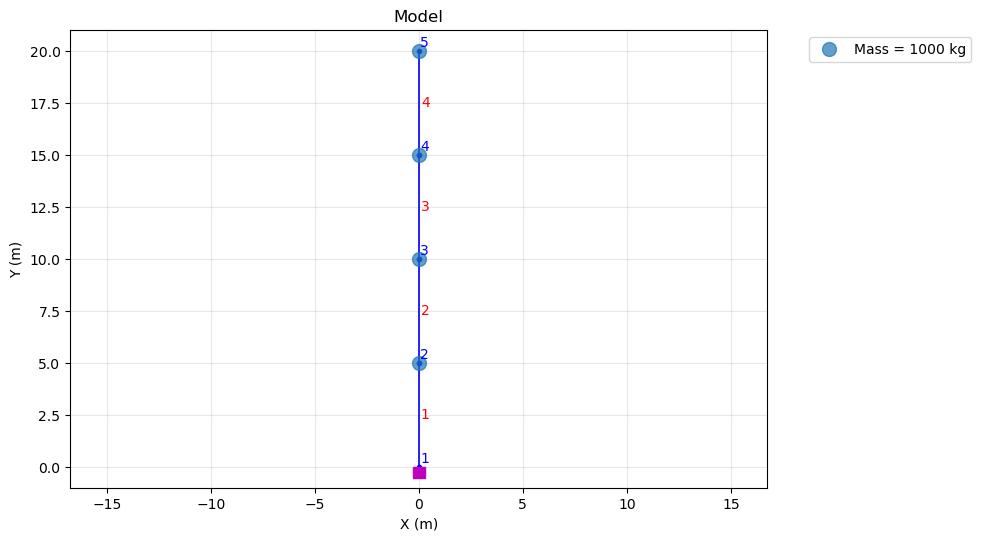

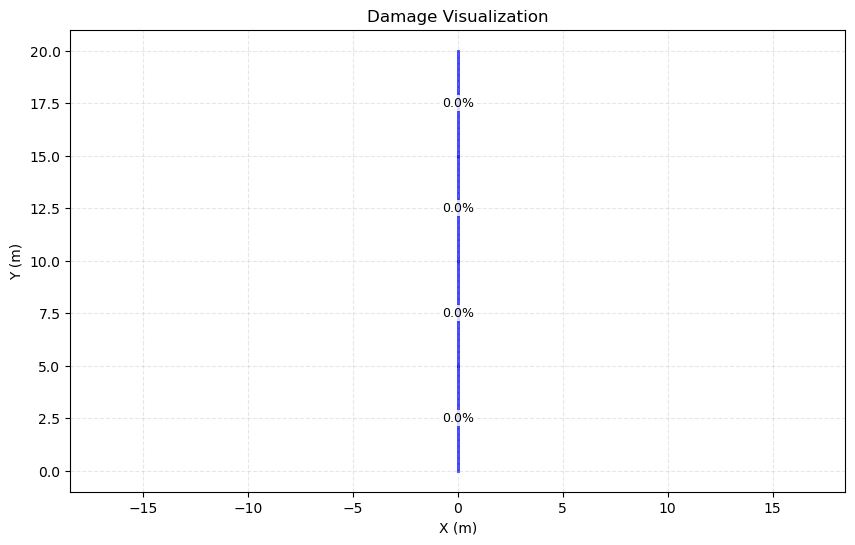


Running: gravity_analysis()
    !Error in applying element loads: iteration over a 0-d array
Applying nodal load of (0.0, -9810.0, 0.0) N to node 2.0
Applying nodal load of (0.0, -9810.0, 0.0) N to node 3.0
Applying nodal load of (0.0, -9810.0, 0.0) N to node 4.0
Applying nodal load of (0.0, -9810.0, 0.0) N to node 5.0
Using sfac = 8.563e+03


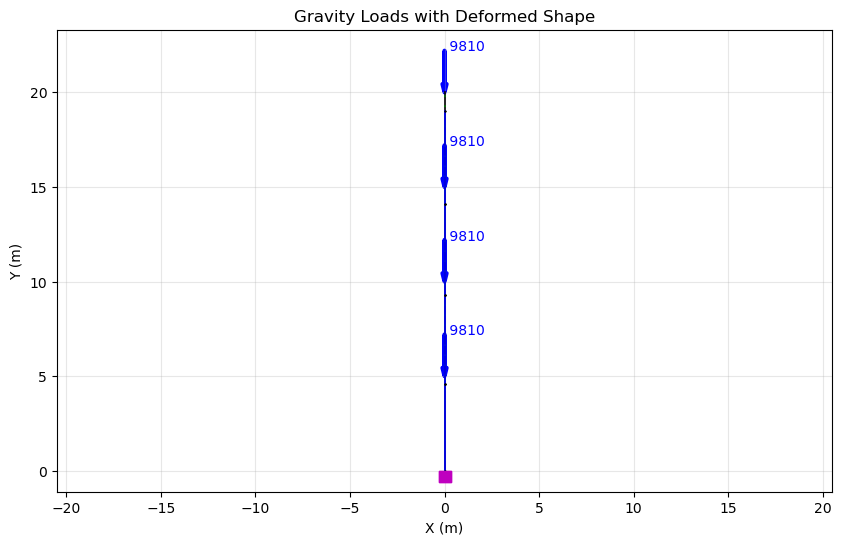

-----------------gravity analysis successfully run--------------------

Running: get_modal_periods()
Number of modes not specified, using n_modes = 4
Mode 1 - period T1 = 0.958 seconds
       - modal participation factor (X direction) = 69.6273
Mode 2 - period T2 = 0.149 seconds
       - modal participation factor (X direction) = 21.0241
Mode 3 - period T3 = 0.053 seconds
       - modal participation factor (X direction) = 6.9392
Mode 4 - period T4 = 0.029 seconds
       - modal participation factor (X direction) = 2.4024


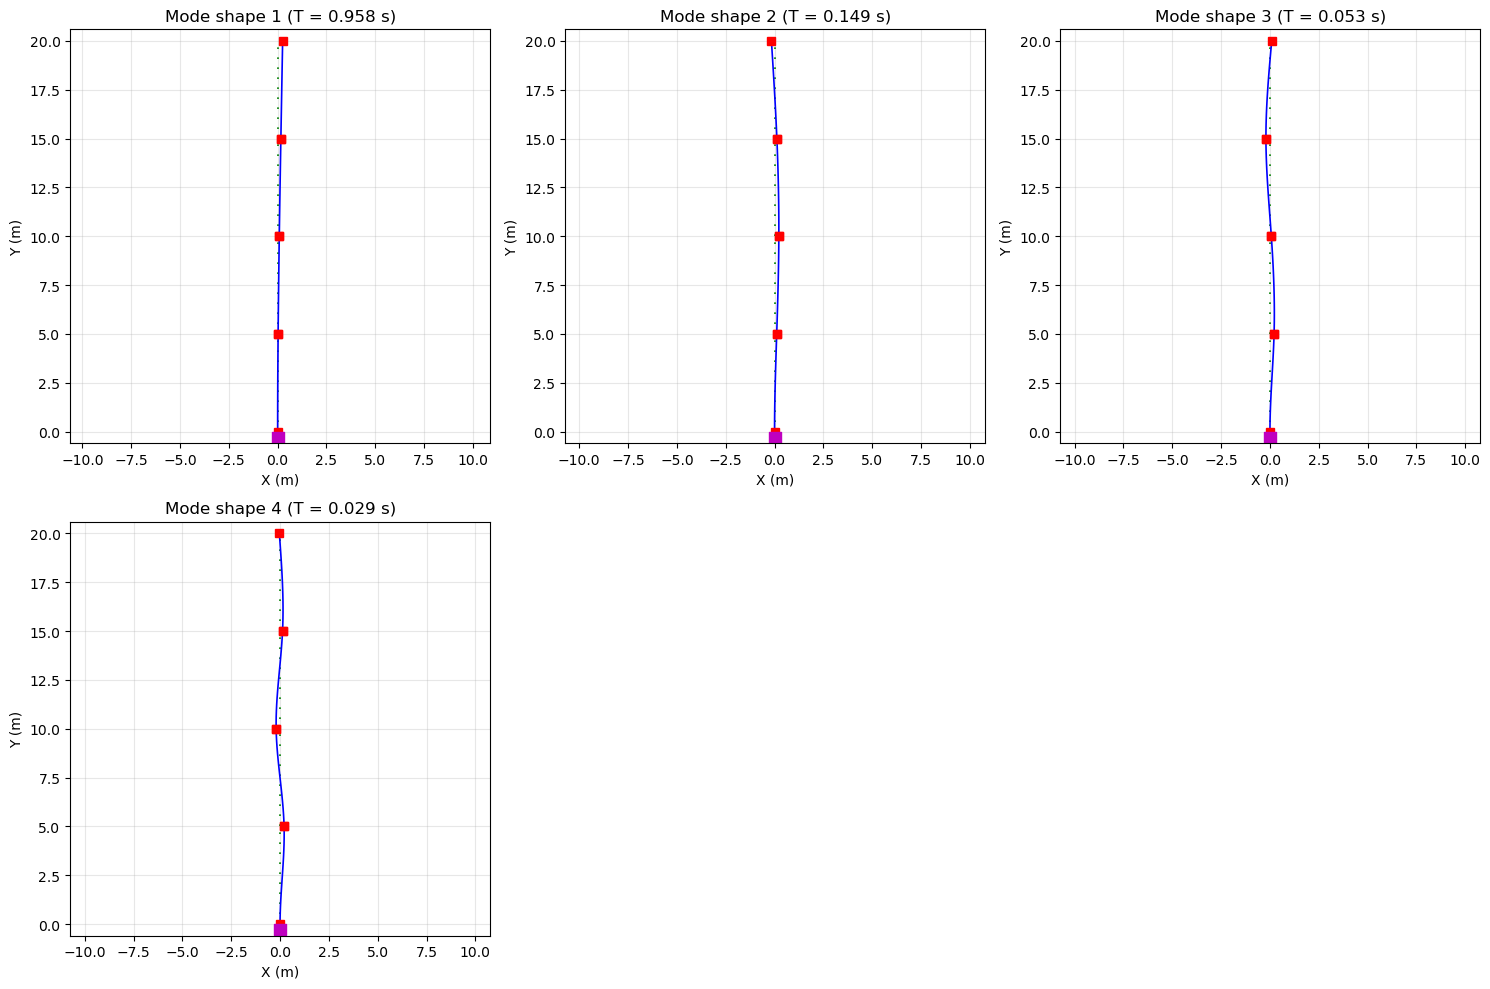

Modal periods (s): [0.95816562 0.14876015 0.0526906  0.02924239]
Modal frequencies (Hz): [ 1.04366091  6.72223044 18.97871864 34.1969293 ]
Modal frequencies (rad/s): [  6.55751487  42.23701954 119.24680614 214.86564374]


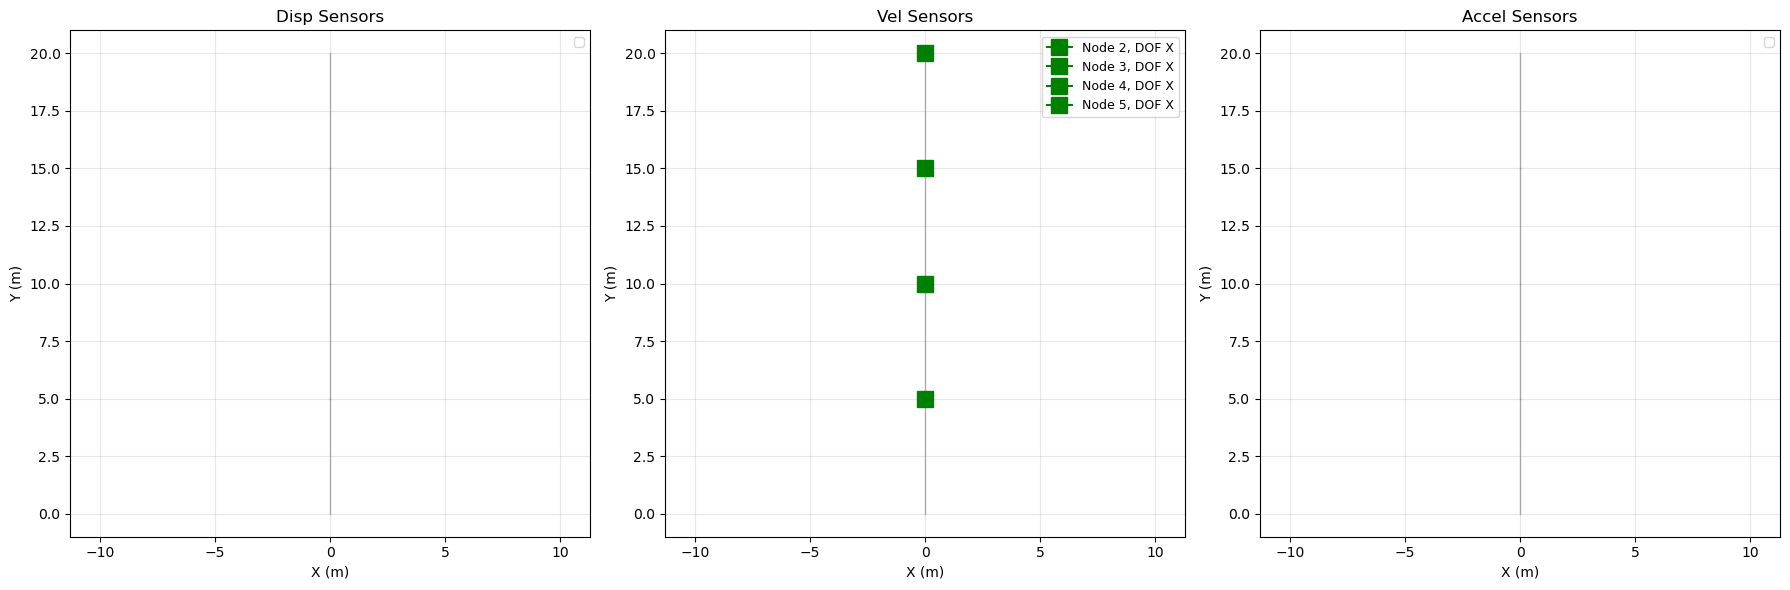

In [1046]:
# x, y coordinates of nodes
X = [
    [0,0],
    [0,5],
    [0,10],
    [0,15],
    [0, 20]
]

# node_i, node_j, material_property_index
IX = [
    [0,1,0],
    [1,2,0], # beam = 1
    [2,3,0],
    [3,4,0]
]

# E, A, I, rho
mprop = [
    # E,     A,    I,     rho
    # [210e9, 0.01, 8.3e-6, 7850], # column
    [210e9, 0.02, 8.3e-4, 7850]  # beam

]

# nodal masses: node_id, mass (kg)
nodeMass = [
    [1, 1000], 
    [2, 1000], 
    [3, 1000],
    [4, 1000]
]


# element loads: element_id, load (N/m),    - load is in the negative y direction (gravity load)
# elementLoad = [
#     [1, -1000]
# ]
elementLoad = None

# nodal loads: node_id, load_x, load_y, load_z
nodeLoad = [
    [1, 0, -1000*9.81, 0], 
    [2, 0, -1000*9.81, 0], 
    [3, 0, -1000*9.81, 0], 
    [4, 0, -1000*9.81, 0],

]
# nodeLoad = None


# node_id, fix_x, fix_y, fix_rotation
bounds = [
    [0,1,1,1],
]

### setup model
# model = SHMStructure(X, IX, mprop, nodeMass, elementLoad, nodeLoad, bounds, print_code=False, plot_code=False)
# FEM = FEM_class(X, IX, mprop, nodeMass, elementLoad, nodeLoad, bounds, print_code=True, plot_code=False)
FEM = FEM_class(X, IX, mprop, nodeMass, elementLoad, nodeLoad, bounds, print_code=True, plot_code=True)

## Stiffness reduction
# model.set_damage(elem_ids=[0], level=0.01)
# model.set_damage(elem_ids=[1], level=0.2)
# model.set_damage(elem_ids=[2], level=0.4)

# add ground motion data
filename = 'data/ambient_excitation_10min.npz'
data = np.load(filename)
dt = data['dt']
acc_filtered = data['acc']
FEM.add_ground_motion(acc_filtered, dt, load_factor=40)



## Build the model
# model.build_model(plot_code=True)
FEM.build_model(plot_code=False) 
FEM.plot_damage()

## Run gravity analysis
# model.gravity_analysis(n_steps=10, plot_code=True)
FEM.gravity_analysis(n_steps=10, plot_code=False)


## Run dynamic analysis with ground motion
FEM.get_modal_periods()
print("Modal periods (s):", FEM.modal_periods)
print("Modal frequencies (Hz):", 1/np.array(FEM.modal_periods))
print("Modal frequencies (rad/s):", 2*np.pi/np.array(FEM.modal_periods))

# plot sensor locations on the structure


# add sensors
# dof: 0=x, 1=y, 2=rotation
# type: 0=disp, 1=vel, 2=acc
# FEM.add_sensor(node=0, dof=0, type=2)
FEM.add_sensor(node=1, dof=0, type=1) 
FEM.add_sensor(node=2, dof=0, type=1) 
FEM.add_sensor(node=3, dof=0, type=1) 
FEM.add_sensor(node=4, dof=0, type=1) 

FEM.plot_sensors_on_structure()


## Geometry 

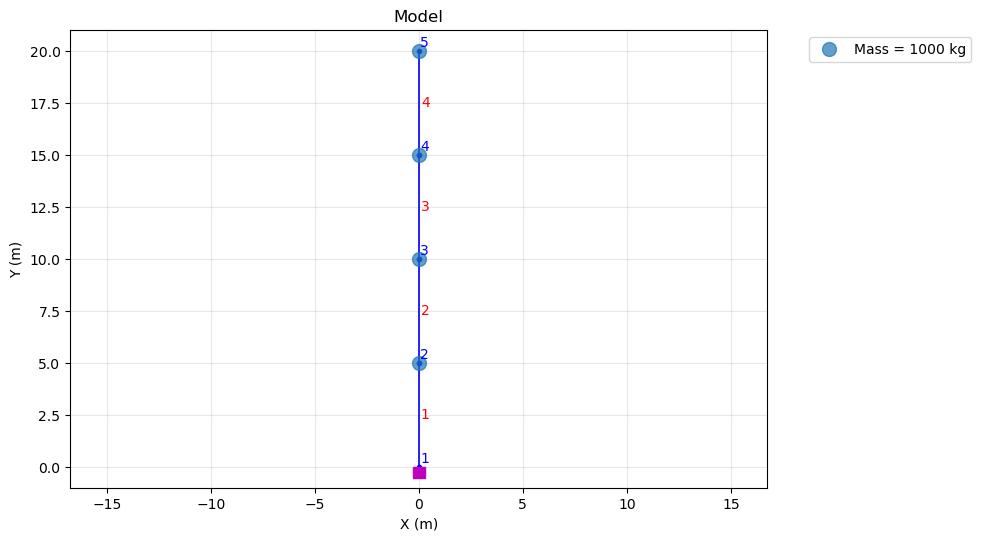

In [1047]:
#| output: True
FEM.plot_model()


## Mode Shapes

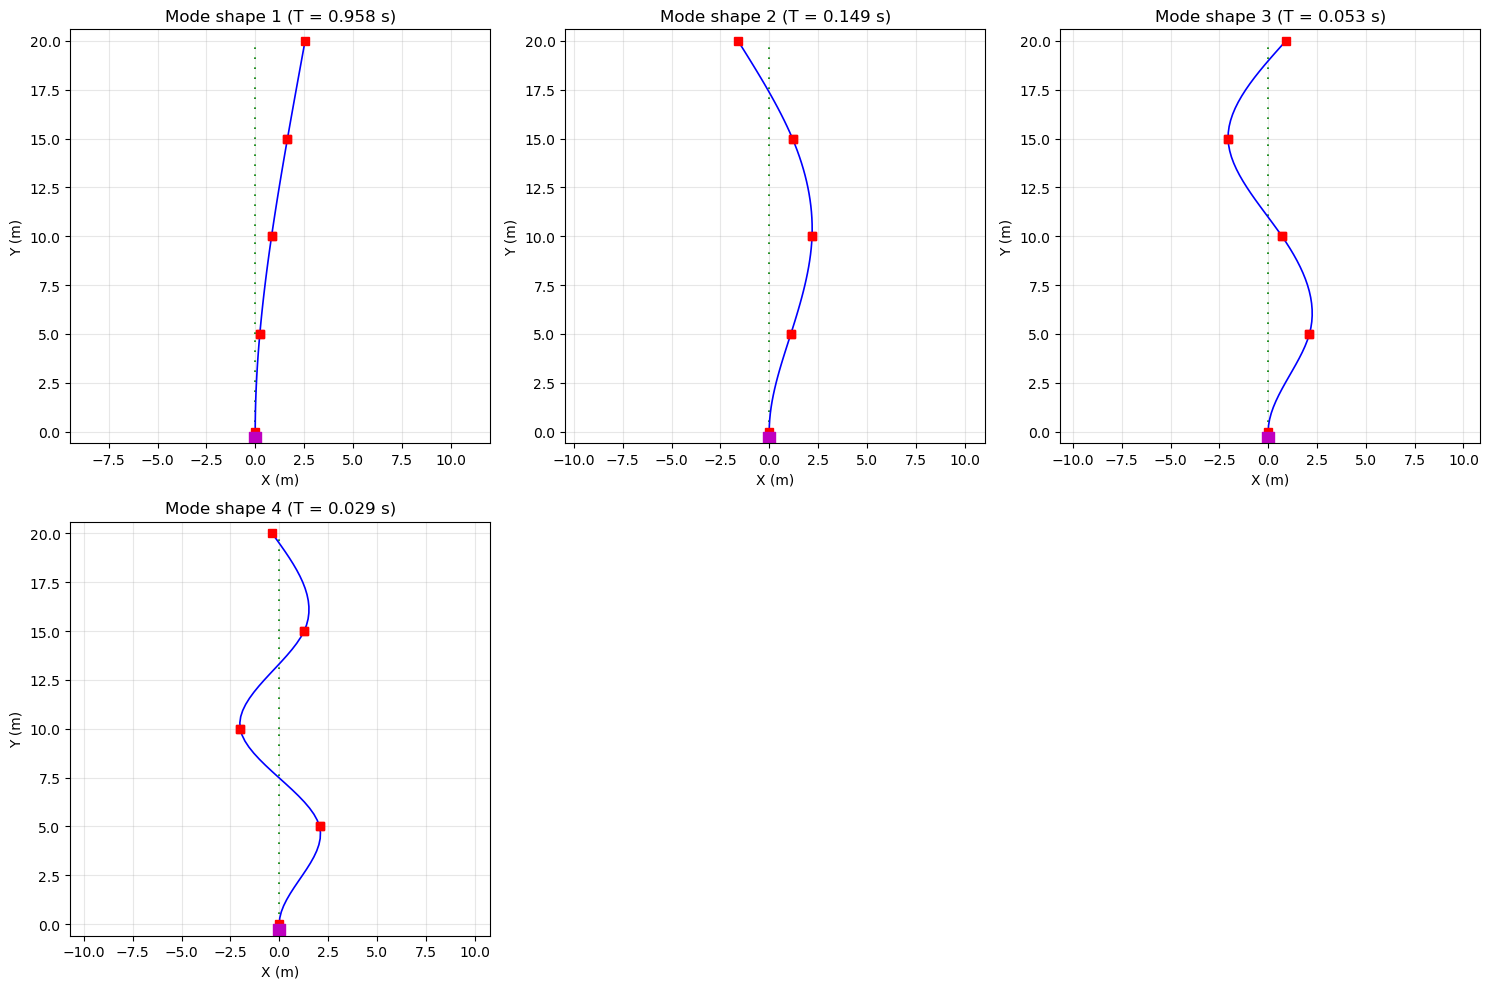

In [1048]:
#| output: True

# plot the first 4 mode shapes for the undamaged and damaged cases
FEM.plot_mode_shapes(n_modes=4, scale = 10)

## Damaged scenarios

In [1049]:
from python_code.OMA_class import OMA_class
OMA = OMA_class(print_code=True, plot_code=False)

OMA.extract_all_feature_cases(FEM, damage_level=0.5, name="damage_scenarios.npz")

OMA

Number of damage scenarios: 16, 2^4 = 16
Running scenario 1/16 with damage combination: (0, 0, 0, 0)
Modal periods for scenario 1: [0.95816562 0.14876015 0.0526906  0.02924239]
Modal frequencies for scenario 1 (Hz): [ 1.04366091  6.72223044 18.97871864 34.1969293 ]
Running scenario 2/16 with damage combination: (0, 0, 0, 1)
Modal periods for scenario 2: [0.96138181 0.15688533 0.05902695 0.03058367]
Modal frequencies for scenario 2 (Hz): [ 1.04016946  6.37408214 16.94141413 32.69718732]
Running scenario 3/16 with damage combination: (0, 0, 1, 0)
Modal periods for scenario 3: [0.99208135 0.1754138  0.05760782 0.0323826 ]
Modal frequencies for scenario 3 (Hz): [ 1.00798185  5.70080569 17.35875549 30.8807843 ]
Running scenario 4/16 with damage combination: (0, 0, 1, 1)
Modal periods for scenario 4: [0.99528831 0.18203601 0.06286112 0.03346283]
Modal frequencies for scenario 4 (Hz): [ 1.00473399  5.49341868 15.90808363 29.88390605]
Running scenario 5/16 with damage combination: (0, 1, 0, 0)

Damage scenarios: 
[(0, 0, 0, 0), (0, 0, 0, 1), (0, 0, 1, 0), (0, 0, 1, 1), (0, 1, 0, 0), (0, 1, 0, 1), (0, 1, 1, 0), (0, 1, 1, 1), (1, 0, 0, 0), (1, 0, 0, 1), (1, 0, 1, 0), (1, 0, 1, 1), (1, 1, 0, 0), (1, 1, 0, 1), (1, 1, 1, 0), (1, 1, 1, 1)]
size of theta: 16
Plot of case: (1, 1, 1, 1): 


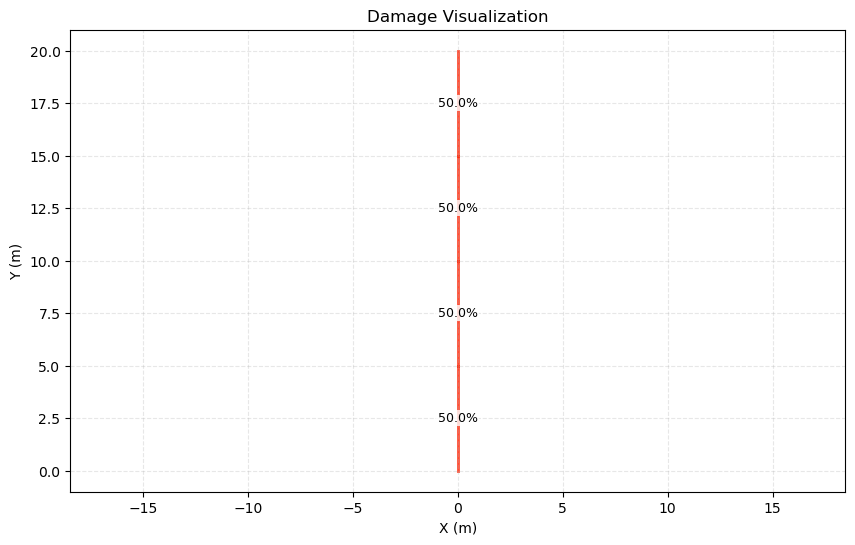

In [1050]:
#| output: True

# see the damage scenarios
print(f"Damage scenarios: \n{OMA.theta}")
print(f"size of theta: {len(OMA.theta)}")
print(f"Plot of case: {OMA.theta[-1]}: ")
FEM.plot_damage()


## Sensor configurations

In [1051]:
#| echo: true
#| output: true
# nodes  
e_sensor = np.arange(len(X))

# list of fixed nodes
fixed_nodes = [bounds[i][0] for i in range(len(bounds))]
fixed_nodes
# remove fixed nodes
e_sensor = e_sensor[~np.isin(e_sensor, fixed_nodes)] # ~ is the logical NOT operator, which inverts the boolean array returned by np.isin
print(f"Sensor nodes: {e_sensor}")

# make an list whit all possible combinations of sensor placements
import itertools # generate the solution space of all possible combinations.
# e_configuration = list(itertools.combinations(e_sensor.tolist(), 3))
e_configuration =  np.array(list(itertools.product([0, 1], repeat=len(e_sensor)))) # all combinations of 0 and 1 for each sensor node
e_configuration = e_configuration 
print(f"Number of sensor configurations: {len(e_configuration)}")
for i in range(len(e_configuration)):
    print(f"Configuration {i} given in nodes with sensors: {e_configuration[i]}")

Sensor nodes: [1 2 3 4]
Number of sensor configurations: 16
Configuration 0 given in nodes with sensors: [0 0 0 0]
Configuration 1 given in nodes with sensors: [0 0 0 1]
Configuration 2 given in nodes with sensors: [0 0 1 0]
Configuration 3 given in nodes with sensors: [0 0 1 1]
Configuration 4 given in nodes with sensors: [0 1 0 0]
Configuration 5 given in nodes with sensors: [0 1 0 1]
Configuration 6 given in nodes with sensors: [0 1 1 0]
Configuration 7 given in nodes with sensors: [0 1 1 1]
Configuration 8 given in nodes with sensors: [1 0 0 0]
Configuration 9 given in nodes with sensors: [1 0 0 1]
Configuration 10 given in nodes with sensors: [1 0 1 0]
Configuration 11 given in nodes with sensors: [1 0 1 1]
Configuration 12 given in nodes with sensors: [1 1 0 0]
Configuration 13 given in nodes with sensors: [1 1 0 1]
Configuration 14 given in nodes with sensors: [1 1 1 0]
Configuration 15 given in nodes with sensors: [1 1 1 1]


## Modal parameters

In [1052]:
load = np.load("data/damage_scenarios.npz")
print("Damage scenarios:")
for key in load:
    print(key)

Damage scenarios:
combinations
periods
natural_frequencies
mode_shapes
damage_level


In [1053]:
load["natural_frequencies"].shape

(16, 4)

In [1054]:
#| output: True
print("damgae levels:", load["damage_level"])

# print the first 4 natural frequencies for the undamaged and damaged cases
print("Undamaged case:")
print("Natural frequencies (Hz = s^-1):", load["natural_frequencies"][0, :24])

print("\nDamaged cases:")
print("Natural frequencies (Hz = s^-1):")
print(load["natural_frequencies"][1:, :4])

damgae levels: 0.5
Undamaged case:
Natural frequencies (Hz = s^-1): [ 1.04366091  6.72223044 18.97871864 34.1969293 ]

Damaged cases:
Natural frequencies (Hz = s^-1):
[[ 1.04016946  6.37408214 16.94141413 32.69718732]
 [ 1.00798185  5.70080569 17.35875549 30.8807843 ]
 [ 1.00473399  5.49341868 15.90808363 29.88390605]
 [ 0.92507043  6.23371597 17.46866929 29.94624496]
 [ 0.92258776  5.98730864 15.53564471 28.45986456]
 [ 0.89964709  5.47467477 15.84453593 27.52478695]
 [ 0.89730897  5.30595967 14.55257746 26.51025891]
 [ 0.81195442  6.13035947 17.10851368 31.24638691]
 [ 0.8103798   5.84807262 15.44423139 29.33255978]
 [ 0.79530858  5.19322953 15.73551334 27.80517814]
 [ 0.79379421  5.01930311 14.58691439 26.49373766]
 [ 0.75271929  5.54133756 15.97818712 27.94024187]
 [ 0.75143744  5.35573313 14.35609552 26.10050471]
 [ 0.73921667  4.8848373  14.48859379 25.43674128]
 [ 0.7379797   4.75333473 13.41998065 24.1808806 ]]


In [1055]:
#| echo: true
#| output: true
"""Only horizontal dof's and then normalize the mode shapes"""
# normiles the node shapes 
mode_shapes = load["mode_shapes"][:, :, 0::3].astype(float)


# Remove fixed nodes from mode_shapes (last axis = node index)
mode_shapes = mode_shapes[:, :, e_sensor]
print(f"Kept sensor nodes in mode_shapes: {e_sensor}")


# Normalize each mode shape by its maximum absolute value
max_abs = np.max(np.abs(mode_shapes), axis=-1, keepdims=True)
max_abs[max_abs == 0] = 1
mode_shapes = mode_shapes / max_abs


# 
mode_shapes.shape, mode_shapes[0, :]

Kept sensor nodes in mode_shapes: [1 2 3 4]


((16, 4, 4),
 array([[ 0.09252781,  0.32807894,  0.64695444,  1.        ],
        [ 0.50514687,  1.        ,  0.54397217, -0.72646916],
        [ 1.        ,  0.33469417, -0.97230886,  0.42654924],
        [ 1.        , -0.96793156,  0.61740502, -0.17421531]]))

# Covariance matrix {.scrollable}

## Plot's 

In [1056]:
# frequencyes and mode shapes
omega_all = load["natural_frequencies"]
phi_all = mode_shapes

# Coefficient of variation (CV)
CV_omega = 0.1
sigma_phi = 0.4

# Prior probabilities for the states (theta)
prior_theta 

# Number of Samples 
N = 10**4

# Instantiate the BR class
BRinf = BR(omega_all, phi_all, CV_omega, sigma_phi, prior, N)

<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\o'
C:\Users\axiom\AppData\Local\Temp\ipykernel_23692\3068820137.py:11: SyntaxWarning: invalid escape sequence '\o'
  plt.title('Covariance Matrix Diagonal Values for $\omega_{1,2,3,4}$ and $\phi_{1,2,3,4}$')


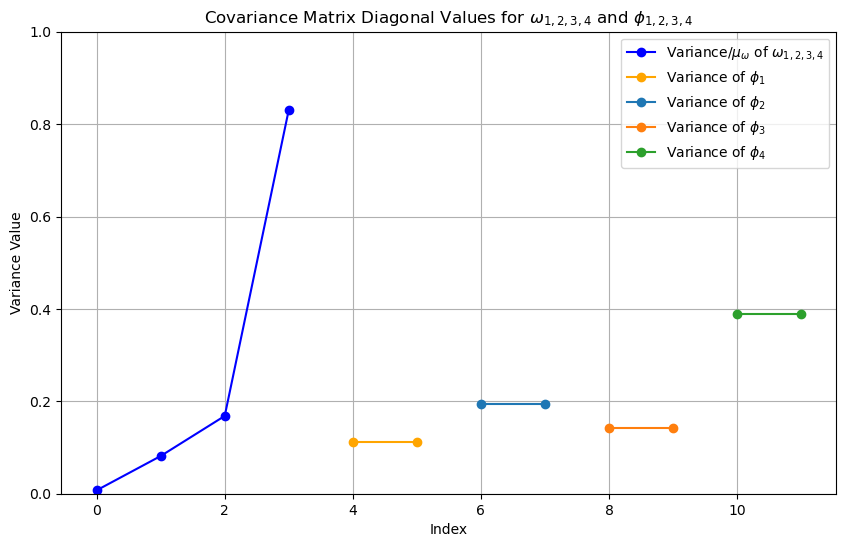

Covariance matrix:
 [1.000e-02 5.500e-01 3.200e+00 2.842e+01 1.100e-01 1.100e-01 1.900e-01
 1.900e-01 1.400e-01 1.400e-01 3.900e-01 3.900e-01]
Sensor configuration: [0 0 1 1]


In [1057]:
#| output: true

# Sensor configuration
# S = e_configuration[3]
S = np.array( [0, 0, 1, 1])

BRinf.covariance_matrix(S)


plt.figure(figsize=(10, 6))
plt.title('Covariance Matrix Diagonal Values for $\omega_{1,2,3,4}$ and $\phi_{1,2,3,4}$')
plt.plot(BRinf.cov.diagonal()[:omega_all.shape[1]]/omega_all[0], marker='o', label=r'Variance/$\mu_\omega$ of $\omega_{1,2,3,4}$', color='blue')
plt.plot(range(omega_all.shape[1], omega_all.shape[1] +np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1]:omega_all.shape[1] + np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_1$', color='orange')
plt.plot(range(omega_all.shape[1] + np.sum(S, dtype=int), omega_all.shape[1] + 2* np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1] + np.sum(S, dtype=int):omega_all.shape[1] + 2* np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_2$')
plt.plot(range(omega_all.shape[1] + 2* np.sum(S, dtype=int), omega_all.shape[1] + 3* np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1] + 2* np.sum(S, dtype=int):omega_all.shape[1] + 3* np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_3$')
plt.plot(range(omega_all.shape[1] + 3* np.sum(S, dtype=int), omega_all.shape[1] + 4* np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1] + 3* np.sum(S, dtype=int):omega_all.shape[1] + 4* np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_4$')
plt.xlabel('Index')
plt.ylabel('Variance Value')
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.show()

print("Covariance matrix:\n", np.round(np.diag(BRinf.cov), 2))
print(f"Sensor configuration: {S}")

<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
C:\Users\axiom\AppData\Local\Temp\ipykernel_23692\2143589287.py:9: SyntaxWarning: invalid escape sequence '\o'
  plt.title('Covariance Matrix Diagonal Values for $\omega_{1,2,3,4}$ and $\phi_{1,2,3,4}$')


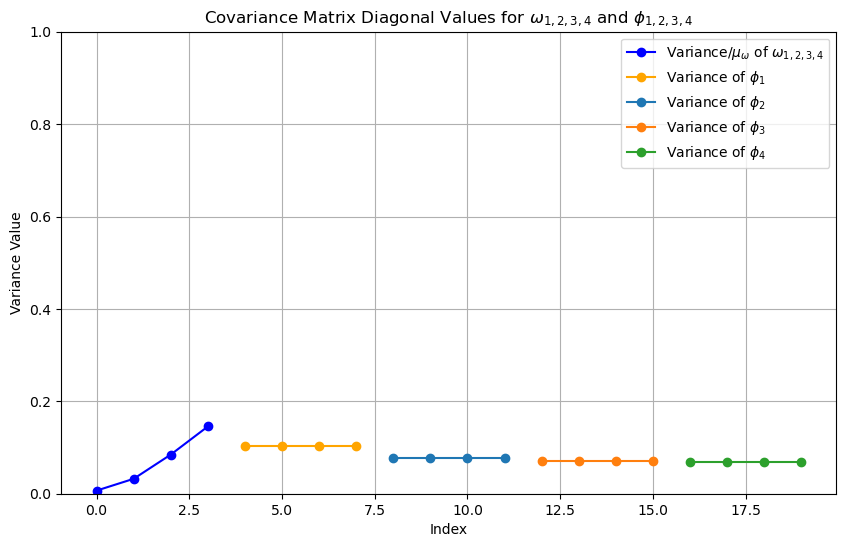

Covariance matrix:
 [0.01 0.22 1.61 4.98 0.1  0.1  0.1  0.1  0.08 0.08 0.08 0.08 0.07 0.07
 0.07 0.07 0.07 0.07 0.07 0.07]
Sensor configuration: [1 1 1 1]


In [1058]:
#| output: true

# S = e_configuration[-1]
S = np.array( [1, 1, 1, 1])

BRinf.covariance_matrix(S)

plt.figure(figsize=(10, 6))
plt.title('Covariance Matrix Diagonal Values for $\omega_{1,2,3,4}$ and $\phi_{1,2,3,4}$')
plt.plot(BRinf.cov.diagonal()[:omega_all.shape[1]]/omega_all[0], marker='o', label=r'Variance/$\mu_\omega$ of $\omega_{1,2,3,4}$', color='blue')
plt.plot(range(omega_all.shape[1], omega_all.shape[1] +np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1]:omega_all.shape[1] + np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_1$', color='orange')
plt.plot(range(omega_all.shape[1] + np.sum(S, dtype=int), omega_all.shape[1] + 2* np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1] + np.sum(S, dtype=int):omega_all.shape[1] + 2* np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_2$')
plt.plot(range(omega_all.shape[1] + 2* np.sum(S, dtype=int), omega_all.shape[1] + 3* np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1] + 2* np.sum(S, dtype=int):omega_all.shape[1] + 3* np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_3$')
plt.plot(range(omega_all.shape[1] + 3* np.sum(S, dtype=int), omega_all.shape[1] + 4* np.sum(S, dtype=int)), BRinf.cov.diagonal()[omega_all.shape[1] + 3* np.sum(S, dtype=int):omega_all.shape[1] + 4* np.sum(S, dtype=int)], marker='o', label=r'Variance of $\phi_4$')

plt.xlabel('Index')
plt.ylabel('Variance Value')
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.show()

print("Covariance matrix:\n", np.round(np.diag(BRinf.cov), 2))
print(f"Sensor configuration: {S}")

# Analysis 1

- **Evaluation method**: Monte Carlo simulation (MCS)
- **likelihood**: Explicit likelihood for Modal properties (no use of features)
- **Decision rule**: Maximum a posteriori (MAP) decision rule $d(y) = \arg\max_{H} p(H \mid y)$

## Workflow - Normal

<!-- ::: panel-tabset

### Normal -->


```{mermaid}
%%| fig-align: center
%%| fig-width: 100%
%%| fig-format: svg
%%| echo: false
%%| output: true
%%{init: {'flowchart': {'useMaxWidth': true}}}%%

flowchart TB
    subgraph SensorDesign["Sensor configurations: e    ."]
        direction TB
        style SensorDesign fill:#e8f5e9,stroke:#2e7d32,stroke-width:3px,color:#1b5e20
        
            
        subgraph Measurement["Monte Carlo Simulations: N    ......"]
            direction TB
            style Measurement fill:#fff3e0,stroke:#e65100,stroke-width:3px,color:#bf360c

            D2 --> B

            A2{"Structural strategy (MCS)<br/> θ* ~ P(θ)"}
            B2{"Generate error (MCS)<br/> ε(e) ~ f(ε | e)"}
            C2["Features<br/>y = g(θ*, e) + ε(e)"] 

            

            A2 --> B2
            B2 --> C2
            C2 --> D2

            style C2 D2 fill:#ffebee,stroke:#c62828,stroke-width:2px,color:#b71c1c
            style D2 fill:#ffebee,stroke:#c62828,stroke-width:2px,color:#b71c1c
            style B fill:#ffebee,stroke:#c62828,stroke-width:2px,color:#b71c1c

            subgraph StructuralState["Structural states: θ    ."]
                direction TB
                style StructuralState fill:#e3f2fd,stroke:#1565c0,stroke-width:3px,color:#0d47a1

                D2{"Likelihood of observation (MCS)<br/>f(y | θ)"}
                B["Likelihood<br/>f(y | H) = ∑<sub>θ</sub> f(y | θ) P(θ | H)"]
                end

        subgraph DamageNoDamage["Structural categories: H    ."]
            direction TB
            style DamageNoDamage fill:#fff9c4,stroke:#f57f17,stroke-width:3px,color:#e65100
        
            C["Posterior<br/>P(H | y)"]
            D["Decision Rule<br/>d = max P(H | y)"]
            end
        E["Loss function<br/> L(H, d) "]

        B --> C
        C --> D
        D --> E
        F["Bayes Risk<br/> Ψ(e) =1/N  ∑<sub>N</sub>  L(H, d)"]


        end

        E --> F


        H["Optimization<br/>e* = argmin Ψ(e)"]
        F --> H
    end
```



## Workflow - Explicit likelihood

```{mermaid}
%%| fig-align: center
%%| fig-width: 100%
%%| fig-format: svg
%%| echo: false
%%| output: true
%%{init: {'flowchart': {'useMaxWidth': true}}}%%
flowchart TB
    subgraph SensorDesign["Sensor configurations: e    ."]
        direction TB
        style SensorDesign fill:#e8f5e9,stroke:#2e7d32,stroke-width:3px,color:#1b5e20
        
            
        subgraph Measurement["Monte Carlo Simulations: N    ......"]
            direction TB
            style Measurement fill:#fff3e0,stroke:#e65100,stroke-width:3px,color:#bf360c

            D2 --> B

            A2{"Structural strategy (MCS)<br/> θ* ~ P(θ)"}
            B2{"Generate error (MCS)<br/> ε(e) ~ f(ε | e)"}

            

            A2 --> B2
            B2 --> D2

            style D2 fill:#ffebee,stroke:#c62828,stroke-width:2px,color:#b71c1c
            style B fill:#ffebee,stroke:#c62828,stroke-width:2px,color:#b71c1c

            subgraph StructuralState["Structural states: θ    ."]
                direction TB
                style StructuralState fill:#e3f2fd,stroke:#1565c0,stroke-width:3px,color:#0d47a1

                D2{"Likelihood of observation (MCS)<br/>f(ε(e) | θ)"}
                B["Likelihood<br/>f(ε(e) | H) = ∑<sub>θ</sub> f(ε(e) | θ) P(θ | H)"]
                end

        subgraph DamageNoDamage["Structural categories: H    ."]
            direction TB
            style DamageNoDamage fill:#fff9c4,stroke:#f57f17,stroke-width:3px,color:#e65100
        
            C["Posterior<br/>P(H | ε(e))"]
            D["Decision Rule<br/>d = max P(H | ε(e))"]
            end
        E["Loss function<br/> L(H, d) "]

        B --> C
        C --> D
        D --> E
        F["Bayes Risk<br/> Ψ(e) =1/N  ∑<sub>N</sub>  L(H, d)"]


        end

        E --> F


        H["Optimization<br/>e* = argmin Ψ(e)"]
        F --> H
    end
```

<!-- ::: -->

::: {.notes}
***Explicit likelihood for Modal properties (no use of features)***
:::

## Code - Setup 

In [1059]:
#| echo: true
from scipy.stats import multivariate_normal as mvn
from sklearn.metrics import confusion_matrix

# frequencyes and mode shapes
omega_all = load["natural_frequencies"]
phi_all = mode_shapes

# Coefficient of variation (CV)
CV_omega = 0.1
sigma_phi = 0.1

# Prior probabilities for the states (theta)
prior_theta = prior_theta

# Number of Samples 
N = 10**4

# must have an minimum of 2 sensors to be able to detect damage
e_config_2 = e_configuration[e_configuration.sum(axis=1) >= 2]


theta = OMA.theta
bayes_risk_sensors = np.zeros(len(e_config_2))
cm = np.zeros((len(e_config_2), 2, 2), dtype=int) # confusion matrix for each sensor configuration

# Instantiate the BR class
A1 = BR(omega_all, phi_all, CV_omega, sigma_phi, prior_theta, N)

# MCS for sensor configuration S
# S = e_configuration[-1]
# print(f"Running MCS for sensor configuration: {S}")

# print(f"e_configuration[1:]:\n {e_configuration[1:]}")
for ei, S in enumerate(e_config_2):
    # Generate samples
    A1.MCS_modal(S)

    # print(f"Running MCS for sensor configuration: {S}")

    # Vectorized Likelihood calculation:  pdf = f(y|theta_i)
    pdf_epsilon_all = np.zeros((N, len(theta)))
    for i in range(len(theta)):
        mu = A1.mu_vector(omega_all[i], phi_all[i], S)
        pdf_epsilon_all[:, i] = mvn.pdf(A1.lambda_star - mu, mean=np.zeros_like(mu), cov=A1.cov)

    # Likelihood: f(y|H) = sum_i f(y|theta_i) * P(theta_i|H)
    Likelihood_H0 = pdf_epsilon_all[:, 0] * prior_theta[0] / prior_H[0] # P(theta_i|H) = prior[0] / P_H0 for the undamaged state
    # Sum across all damage states (i=1 to end)
    Likelihood_H1 = np.sum(pdf_epsilon_all[:, 1:] * (prior_theta[1:] / prior_H[1]), axis=1)

    # Posterior probabilities: P(H|y) ∝ f(y|H) * P(H)
    Post0 = Likelihood_H0 * prior_H[0]
    Post1 = Likelihood_H1 * prior_H[1]

    # Decisions rule: maximimum a posteriori (MAP) 
    d_vec = (Post1 > Post0).astype(int)

    # Loss and Bayes Risk
    total_costs = prediction_cost[A1.H_vec, d_vec] + sensor_cost(len(e_configuration[sum(S)]))

    # Confusion matrix
    cm[ei] = confusion_matrix(A1.H_vec, d_vec)

    # Estimation of the bayes risk using Monte Carlo.
    Bayes_Risk = np.mean(total_costs)

    print(f"Bayes Risk: {Bayes_Risk}")
    bayes_risk_sensors[ei] = Bayes_Risk


Bayes Risk: 48.51
Bayes Risk: 49.575
Bayes Risk: 35.7
Bayes Risk: 36.755
Bayes Risk: 48.605
Bayes Risk: 37.84
Bayes Risk: 32.765
Bayes Risk: 39.62
Bayes Risk: 22.915
Bayes Risk: 14.095
Bayes Risk: 17.85


## Bayes risk for different sensor configurations

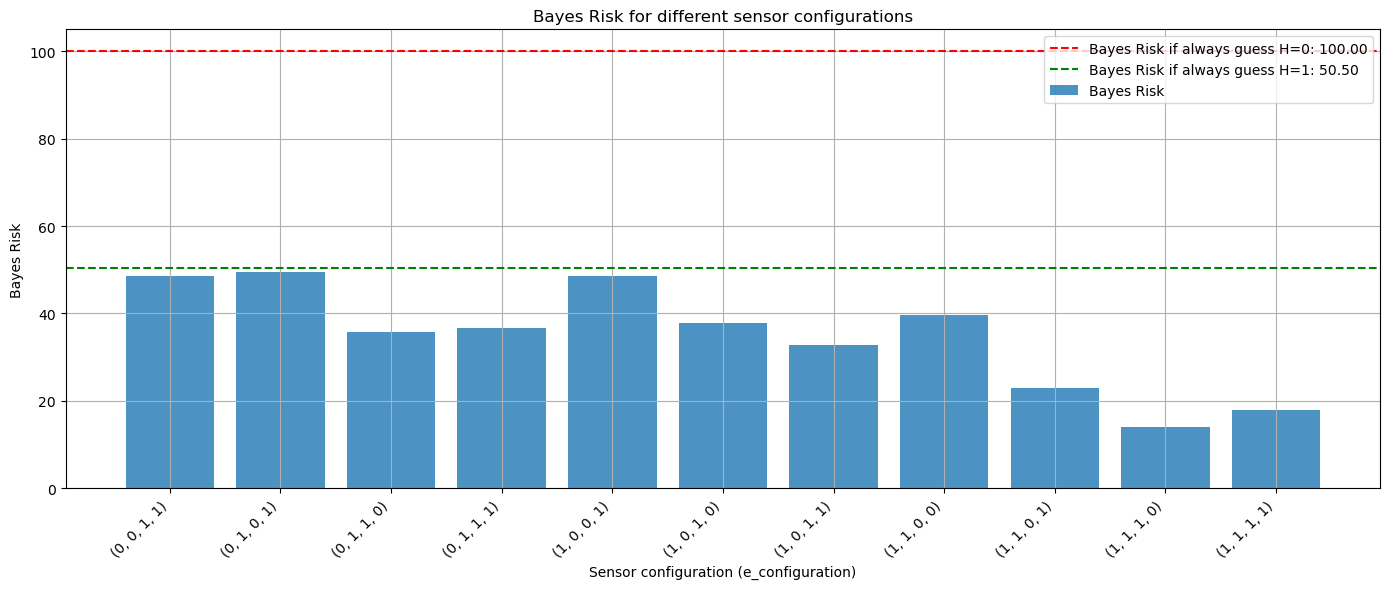

Minimum Bayes Risk: 14.095
Best sensor configuration: [1 1 1 0] (index: 9)


In [1060]:
#| output: True
# bayes_risk_sensors = bayes_risk_sensors - [sensor_cost(len(e_configuration[i])) for i in range(len(e_configuration))]
x = np.arange(len(e_config_2))  # x-axis values for the bar plot
labels = [str(tuple(int(n) for n in cfg)) for cfg in e_config_2]
plt.figure(figsize=(14, 6))
plt.bar(x, bayes_risk_sensors, width=0.8, label="Bayes Risk", alpha=0.8)
# print the bayes risk for each ther always guses H=0 and H=1
BR_H0 = prediction_cost[0, 0] * prior_H[0] + prediction_cost[1, 0] * prior_H[1]
BR_H1 = prediction_cost[0, 1] * prior_H[0] + prediction_cost[1, 1] * prior_H[1]
plt.axhline(BR_H0, color='red', linestyle='--', label=f"Bayes Risk if always guess H=0: {BR_H0:.2f}")
plt.axhline(BR_H1, color='green', linestyle='--', label=f"Bayes Risk if always guess H=1: {BR_H1:.2f}")

plt.xlabel("Sensor configuration (e_configuration)")
plt.ylabel("Bayes Risk")
plt.title("Bayes Risk for different sensor configurations")
plt.xticks(x, labels, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# min bayes risk
min_bayes_risk = np.min(bayes_risk_sensors)
best_config_index = np.argmin(bayes_risk_sensors)
best_config = e_config_2[best_config_index]
print(f"Minimum Bayes Risk: {min_bayes_risk}")
print(f"Best sensor configuration: {best_config} (index: {best_config_index})")

## Confusion matrices - Score's

Confusion matrices:
$$
\text{Confusion Matrix} = \begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$

Recall: 
$$
recall = \frac{TP}{TP + FN}
$$

Precision:
$$
precision = \frac{TP}{TP + FP}
$$

F1-score:
$$
F1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}
$$



## Confusion matrices - Plot 1 

::: {.notes}
Options for comparing Confusion matrices:

- Recall per class
- Precision per class
- F1-score per class
::: 

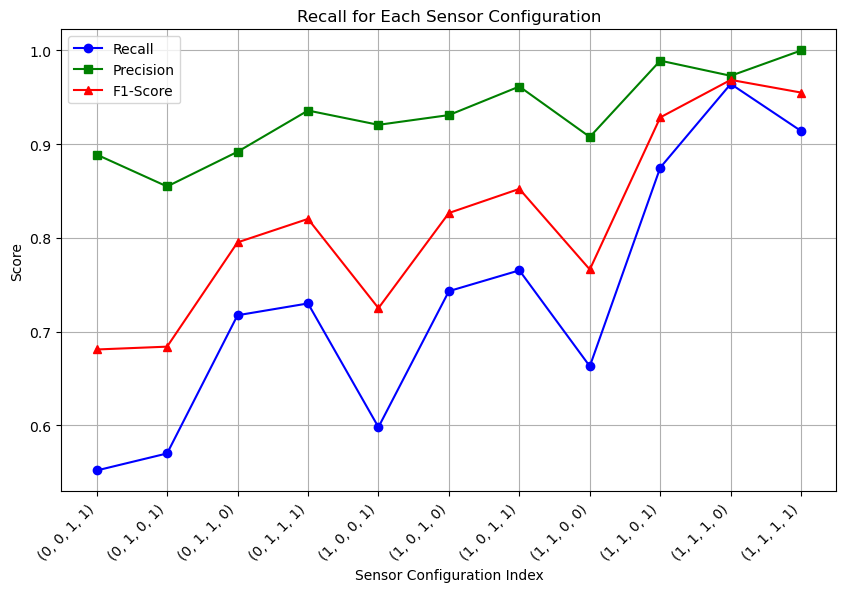

In [1061]:
#| output: true
# plot recall for each sensor configuration
recall = cm[:, 1, 1] / (cm[:, 1, 1] + cm[:, 1, 0] )  # TP / (TP + FN)
precision = cm[:, 1, 1] / (cm[:, 1, 1] + cm[:, 0, 1] ) # TP / (TP + FP)
F1_score = 2 * (precision * recall) / (precision + recall)

x = np.arange(1, len(e_config_2) + 1)  # 1..15 (matches recall length)
labels = [str(tuple(int(n) for n in cfg)) for cfg in e_config_2]  # 15 labels

plt.figure(figsize=(10, 6))
plt.plot(x, recall, marker='o', label='Recall', color='blue')
plt.plot(x, precision, marker='s', label='Precision', color='green')
plt.plot(x, F1_score, marker='^', label='F1-Score', color='red')
plt.xlabel('Sensor Configuration Index')
plt.ylabel('Score')
plt.title('Recall for Each Sensor Configuration')
plt.xticks(x, labels, rotation=45, ha="right")
plt.grid()
plt.legend()
plt.show()

## Confusion matrices - Plot 2

::: {.callout-note}
There is an need for Importance sampling 
:::

::: {.notes}
- Note there is an need for Importance sampling
:::

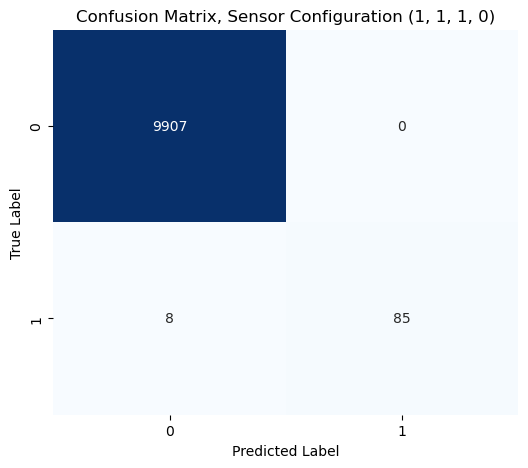

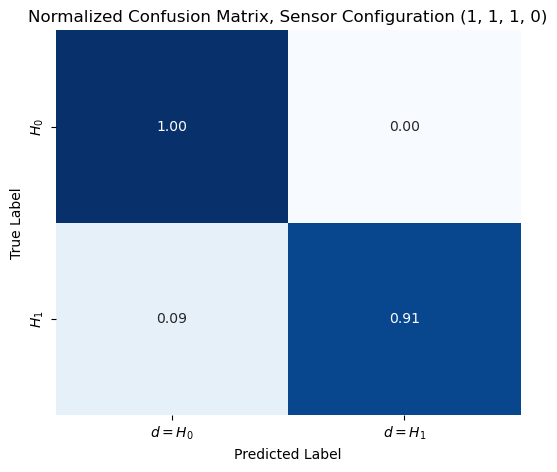

In [1062]:
#| output: true
import seaborn as sns
# Use the best sensor configuration
best_S = best_config
y_test_best = A1.H_vec  # True labels from the last MCS run
y_pred_best = d_vec     # Predictions from the last MCS run

# Plot the confusion matrix
# cm_best = confusion_matrix(y_test_best, y_pred_best)
cm_best = confusion_matrix(y_test_best, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix, Sensor Configuration {tuple(map(int, best_S))}')
plt.show()

# Plot the normalized confusion matrix
cm_best_normalized = confusion_matrix(y_test_best, y_pred_best, normalize='true')
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_normalized, annot=True, fmt='.2f', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.xticks([0.5, 1.5], [r'$d=H_0$', r'$d=H_1$'])
plt.ylabel('True Label')
plt.yticks([0.5, 1.5], [r'$H_0$', r'$H_1$'])
plt.title(f'Normalized Confusion Matrix, Sensor Configuration {tuple(map(int, best_S))}')
plt.show()


## Down sides

Bayesian inference whit the likelihood function:

1. I assume perfect knowledge of the statistical parameters for the error model for an given sensor configuration? 

# Analysis 1.1

- **Evaluation method**: Monte Carlo simulation with importance sampling
- **likelihood**: Explicit likelihood for Modal properties (no use of features)
- **Decision rule**: Maximum a posteriori (MAP) decision rule $d(y) = \arg\max_{H} p(H \mid y)$

## Importance sampling 

Variance reduction of expectation: ^[“9.7 IMPORTANCE SAMPLING” ([Brandimarte, 2014, p. 375](zotero://select/library/items/76GINWSD)) ([pdf](zotero://open-pdf/library/items/SBKGQF3D?page=375&annotation=ZQR4Q7RK))]

$$
E[g(X)] = \int g(x) f(x) dx = \int g(x) w(x) h(x) dx = E_h[g(X) w(X)] \simeq  \frac{1}{N} \sum_{i=1}^{N} g(x_i) w(x_i)
$$

Where: 

- $f(x)$ is the probability density function (PDF) of the original distribution from which we want to sample.
- $g(x)$ is the function we want to compute the expectation of.
- $h(x)$ is the PDF of the proposal distribution. 
- $w(x) = \frac{f(x)}{h(x)}$ is the importance weight, which corrects for the fact that we are sampling from $h(x)$ instead of $f(x)$.

## Importance sampling code

In [1063]:
#| echo: true
#| output: true
from scipy.stats import multivariate_normal as mvn
from sklearn.metrics import confusion_matrix

# frequencyes and mode shapes
omega_all = load["natural_frequencies"]
phi_all = mode_shapes

# Coefficient of variation (CV)
CV_omega = 0.1
sigma_phi = 0.1

# Prior probabilities for the states (theta)
prior_theta = prior_theta

# Number of Samples 
N = 10**4

# must have an minimum of 2 sensors to be able to detect damage
e_config_2 = e_configuration[e_configuration.sum(axis=1) >= 2]


theta = OMA.theta
bayes_risk_sensors = np.zeros(len(e_config_2))
cm = np.zeros((len(e_config_2), 2, 2), dtype=int) # confusion matrix for each sensor configuration

# Instantiate the BR class
A1 = BR(omega_all, phi_all, CV_omega, sigma_phi, prior_theta, N)

# improtance sampling prior for the states (theta) H_0 = 0.5 and H_1 = 0.5
prior_H_Importance = np.array([0.5, 0.5])
prior_Importance = np.concatenate(([prior_H_Importance[0]], np.repeat(prior_H_Importance[1] / (len(prior_theta) - 1), len(prior_theta) - 1)))

print(f"Importance sampling prior probabilities for H: {prior_H_Importance}")
print(f"\nImportance sampling prior probabilities for θ: {np.round(prior_Importance, 4)}")

# print(f"e_configuration[1:]:\n {e_configuration[1:]}")
for ei, S in enumerate(e_config_2):
    # Generate samples
    A1.MCS_modal(S, prior_Importance=prior_Importance)

    # print(f"Running MCS for sensor configuration: {S}")

    # Vectorized Likelihood calculation:  pdf = f(y|theta_i)
    pdf_epsilon_all = np.zeros((N, len(theta)))
    for i in range(len(theta)):
        mu = A1.mu_vector(omega_all[i], phi_all[i], S)
        pdf_epsilon_all[:, i] = mvn.pdf(A1.lambda_star - mu, mean=np.zeros_like(mu), cov=A1.cov)

    # Likelihood: f(y|H) = sum_i f(y|theta_i) * P(theta_i|H)
    Likelihood_H0 = pdf_epsilon_all[:, 0] * prior_theta[0] / prior_H[0] # P(theta_i|H) = prior[0] / P_H0 for the undamaged state
    # Sum across all damage states (i=1 to end)
    Likelihood_H1 = np.sum(pdf_epsilon_all[:, 1:] * (prior_theta[1:] / prior_H[1]), axis=1)

    # Posterior probabilities: P(H|y) ∝ f(y|H) * P(H)
    Post0 = Likelihood_H0 * prior_H[0]
    Post1 = Likelihood_H1 * prior_H[1]

    # Decisions rule: maximimum a posteriori (MAP) 
    d_vec = (Post1 > Post0).astype(int)

    # Loss and Bayes Risk
    total_costs = prediction_cost[A1.H_vec, d_vec] + sensor_cost(len(e_configuration[sum(S)]))

    # Confusion matrix
    cm[ei] = confusion_matrix(A1.H_vec, d_vec)

    # Importance weights for the samples
    w = prior_H/prior_H_Importance
    importance_weights = w[A1.H_vec]  # Get the importance weights for each sample based on its true state H_vec


    # Estimation of the bayes risk using Monte Carlo.
    Bayes_Risk = np.mean(importance_weights * total_costs)

    print(f"Bayes Risk: {Bayes_Risk}")
    bayes_risk_sensors[ei] = Bayes_Risk


Importance sampling prior probabilities for H: [0.5 0.5]

Importance sampling prior probabilities for θ: [0.5    0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333
 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333]
Bayes Risk: 52.273048
Bayes Risk: 47.570064
Bayes Risk: 43.8283
Bayes Risk: 32.355183999999994
Bayes Risk: 50.633292000000004
Bayes Risk: 35.66810400000001
Bayes Risk: 29.192908000000003
Bayes Risk: 36.016716
Bayes Risk: 27.297348
Bayes Risk: 20.894144
Bayes Risk: 15.547128


## Bayes risk for different sensor configurations

::: {.callout-note}
Compare this with the results from non-importance sampling 
:::

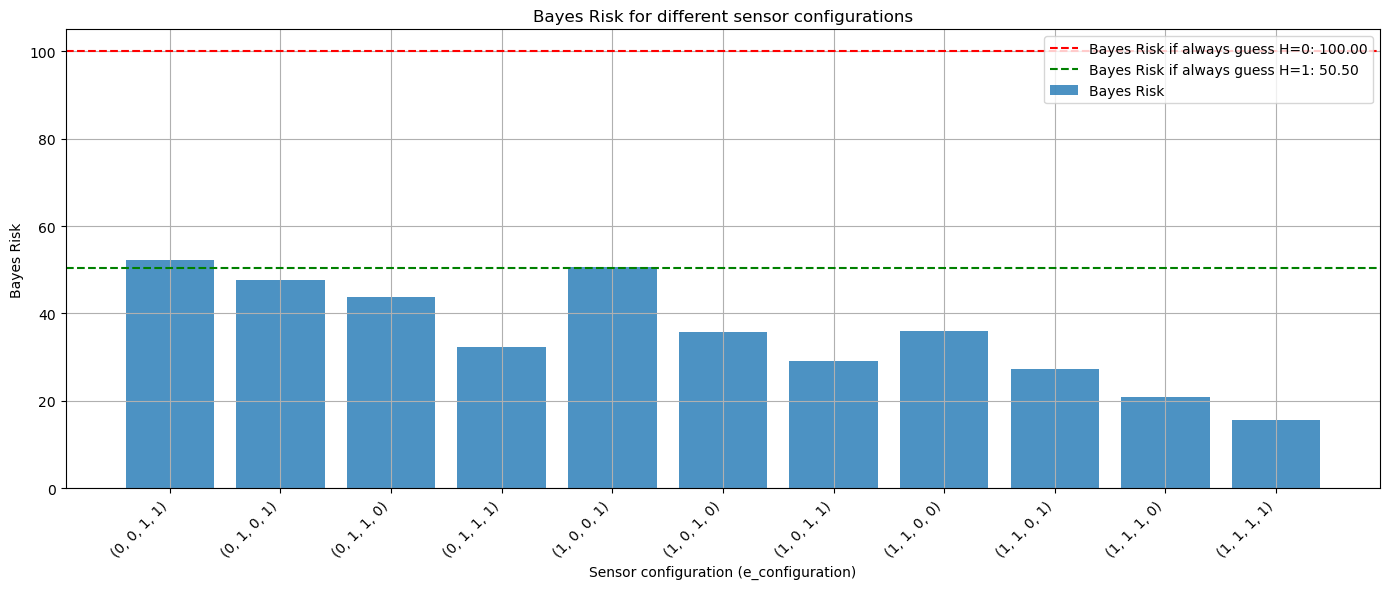

Minimum Bayes Risk: 15.547128
Best sensor configuration: [1 1 1 1] (index: 10)


In [1064]:
#| output: True
# bayes_risk_sensors = bayes_risk_sensors - [sensor_cost(len(e_configuration[i])) for i in range(len(e_configuration))]
x = np.arange(len(e_config_2))  # x-axis values for the bar plot
labels = [str(tuple(int(n) for n in cfg)) for cfg in e_config_2]
plt.figure(figsize=(14, 6))
plt.bar(x, bayes_risk_sensors, width=0.8, label="Bayes Risk", alpha=0.8)
# print the bayes risk for each ther always guses H=0 and H=1
BR_H0 = prediction_cost[0, 0] * prior_H[0] + prediction_cost[1, 0] * prior_H[1]
BR_H1 = prediction_cost[0, 1] * prior_H[0] + prediction_cost[1, 1] * prior_H[1]
plt.axhline(BR_H0, color='red', linestyle='--', label=f"Bayes Risk if always guess H=0: {BR_H0:.2f}")
plt.axhline(BR_H1, color='green', linestyle='--', label=f"Bayes Risk if always guess H=1: {BR_H1:.2f}")

plt.xlabel("Sensor configuration (e_configuration)")
plt.ylabel("Bayes Risk")
plt.title("Bayes Risk for different sensor configurations")
plt.xticks(x, labels, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# min bayes risk
min_bayes_risk = np.min(bayes_risk_sensors)
best_config_index = np.argmin(bayes_risk_sensors)
best_config = e_config_2[best_config_index]
print(f"Minimum Bayes Risk: {min_bayes_risk}")
print(f"Best sensor configuration: {best_config} (index: {best_config_index})")

## Confusion matrices - Plot 1 

::: {.callout-note}
Compare this with the results from non-importance sampling 
:::

::: {.notes}
Options for comparing Confusion matrices:

- Recall per class
- Precision per class
- F1-score per class
::: 

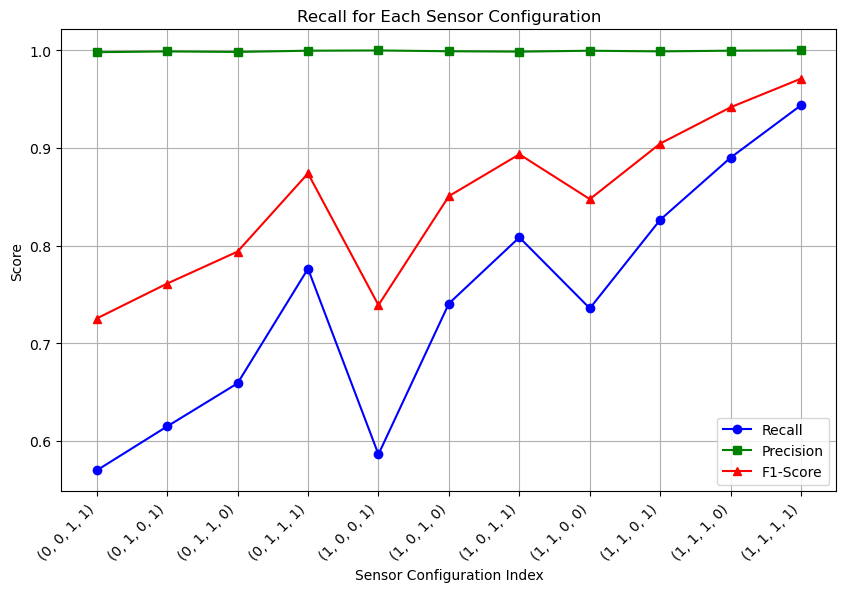

In [1065]:
#| output: true
# plot recall for each sensor configuration
recall = cm[:, 1, 1] / (cm[:, 1, 1] + cm[:, 1, 0] )  # TP / (TP + FN)
precision = cm[:, 1, 1] / (cm[:, 1, 1] + cm[:, 0, 1] ) # TP / (TP + FP)
F1_score = 2 * (precision * recall) / (precision + recall)

x = np.arange(1, len(e_config_2) + 1)  # 1..15 (matches recall length)
labels = [str(tuple(int(n) for n in cfg)) for cfg in e_config_2]  # 15 labels

plt.figure(figsize=(10, 6))
plt.plot(x, recall, marker='o', label='Recall', color='blue')
plt.plot(x, precision, marker='s', label='Precision', color='green')
plt.plot(x, F1_score, marker='^', label='F1-Score', color='red')
plt.xlabel('Sensor Configuration Index')
plt.ylabel('Score')
plt.title('Recall for Each Sensor Configuration')
plt.xticks(x, labels, rotation=45, ha="right")
plt.grid()
plt.legend()
plt.show()

## Confusion matrices - Plot 2

::: {.callout-note}
Now is it good
:::

::: {.notes}
- Note there is an need for Importance sampling
:::

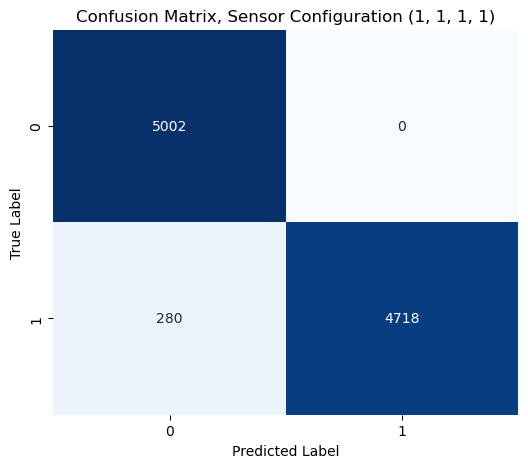

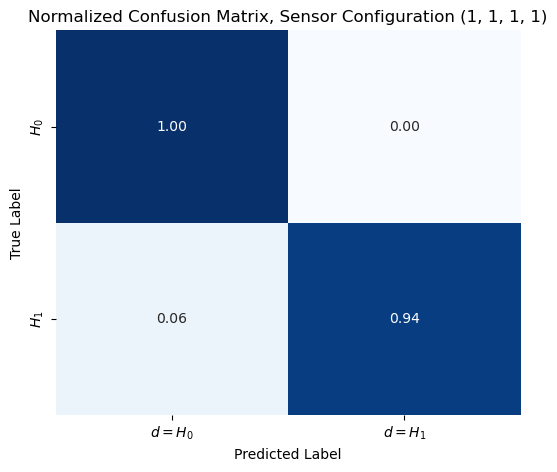

In [1066]:
#| output: true
import seaborn as sns
# Use the best sensor configuration
best_S = best_config
y_test_best = A1.H_vec  # True labels from the last MCS run
y_pred_best = d_vec     # Predictions from the last MCS run

# Plot the confusion matrix
# cm_best = confusion_matrix(y_test_best, y_pred_best)
cm_best = confusion_matrix(y_test_best, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix, Sensor Configuration {tuple(map(int, best_S))}')
plt.show()

# Plot the normalized confusion matrix
cm_best_normalized = confusion_matrix(y_test_best, y_pred_best, normalize='true')
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_normalized, annot=True, fmt='.2f', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.xticks([0.5, 1.5], [r'$d=H_0$', r'$d=H_1$'])
plt.ylabel('True Label')
plt.yticks([0.5, 1.5], [r'$H_0$', r'$H_1$'])
plt.title(f'Normalized Confusion Matrix, Sensor Configuration {tuple(map(int, best_S))}')
plt.show()


# Analysis 2

- **Evaluation method**: Monte Carlo simulation (MCS)
- **likelihood**: No likelihood, use supervised machine learning (ML) classification based on the features.
- **Decision rule**: use the trained ML model to directly classify the structural states based on the features. (no use of likelihood)

## Feature Vector

$$
  X = [ \omega_1, \omega_2, \omega_3, \omega_4, TMAC(H_0, \bar{\boldsymbol\phi}), MF(\bar{\boldsymbol\phi}, \bar{\boldsymbol\omega}) ]
$$

where:

- $\omega_i$: is the $i$-th natural frequency.
- $TMAC(H_0, \bar{\boldsymbol\phi})$: is the Total Modal Assurance Criterion (TMAC) between the mode shapes of the undamaged state $H_0$ and the observed mode shapes $\bar{\boldsymbol\phi}$.
- $MF(\bar{\boldsymbol\phi}, \bar{\boldsymbol\omega})$: is the Modal Flexibility, which is a function of the observed mode shapes $\bar{\boldsymbol\phi}$ and the observed natural frequencies $\bar{\boldsymbol\omega}$.

## Supervised learning - ML 

**General supervised learning model for classification:** ^[“Introduction to classification and regression” ([Herlau et al., p. 137](zotero://select/library/items/4P269CF8)) ([pdf](zotero://open-pdf/library/items/Y7FREX6H?page=151&annotation=VGPXET7Y))]

$$
y = f(x, w) + \epsilon
$$

- $y$: is the class (damage or no damage).
- $x$: is the feature vector.
- $w$: are the weights.
- $f(\cdot)$ is the function that maps the features to the class.
  - This is the decision rule "$d(y)$" that I have used erlier
- $\epsilon$: is the error term, which is there error in the model. 

**Training the models:** ^[“6.5 Bayesian learning in general” ([Herlau et al., p. 109](zotero://select/library/items/4P269CF8)) ([pdf](zotero://open-pdf/library/items/Y7FREX6H?page=123&annotation=6J35P6PS)) - General learning the weights $w$ ]

In general is the estimation of the weights $w$ done by using Maximum Likelihood Estimation (MLE).  

::: {.callout-note}
Many problems do not have an closed-form solution for the MLE, and instead use optimization algorithms to find the weights that maximize the likelihood function.
:::

## ML Classification algorithms

Algorithms for classification:

- [Logistic regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression), [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression)
- [Decision Trees](https://scikit-learn.org/stable/modules/tree.html) (need work)
- [Linear and Quadratic Discriminant Analysis](https://scikit-learn.org/stable/modules/lda_qda.html), [Nice web article](https://uc-r.github.io/discriminant_analysis) (need work)

## Dataset 

::: panel-tabset

### Dataset

Data set for training the logistic regression model:

- $10^3$ samples for each sensor configuration
- 50% class 0 (no damage)
- 50% class 1 (damage)
  - equal number of each damage senario 

Split:

- 80% training data
- 20% test data




### Dataset Code

In [1067]:
#| echo: true
#| output: true
# frequencyes and mode shapes
omega_all = load["natural_frequencies"]
phi_all = mode_shapes

# Coefficient of variation (CV)
CV_omega = 0.1
sigma_phi = 0.1

# Prior probabilities for the states (theta)
prior_theta = prior_theta

# Number of Samples 
N = 10**3

theta = OMA.theta
e_config_2 = e_configuration[e_configuration.sum(axis=1) >= 2]


theta = OMA.theta
bayes_risk_sensors = np.zeros(len(e_config_2))
cm = np.zeros((len(e_config_2), 2, 2), dtype=int) # confusion matrix for each sensor configuration

# Instantiate the BR class
A2 = BR(omega_all, phi_all, CV_omega, sigma_phi, prior_theta, N)


# improtance sampling prior for the states (theta) H_0 = 0.5 and H_1 = 0.5
prior_Importance = np.concatenate(([0.5], np.repeat(0.5 / (len(prior_theta) - 1), len(prior_theta) - 1)))

y_class = np.zeros(N*(len(e_config_2)))  # true class labels for each sensor configuration
X_features = np.zeros((N*(len(e_config_2)), 6))  # features: omega_bar, TMAC_H0, MF for each sensor configuration

# print(f"e_configuration[1:]:\n {e_configuration[1:]}")
for ei, S in enumerate(e_config_2):
    # Generate samples
    A2.MCS_modal(S, prior_Importance=prior_Importance)
    
    A2.omega_bar
    TMAC_H0 = np.array([A2.TMAC(A2.mask_and_normalize(A2.phi_H0, S), v) for v in A2.phi_bar])
    MF = np.array([A2.MF(phi, omega) for phi, omega in zip(A2.phi_bar, A2.omega_bar)])

    y_class_temp = np.array(A2.H_vec)  # true class labels (0 for H0, 1 for H1)
    X_features_temp = np.column_stack((A2.omega_bar, TMAC_H0, MF))

    y_class[ei*N:(ei+1)*N] = y_class_temp
    X_features[ei*N:(ei+1)*N, :] = X_features_temp


### Split of dataset

In [1068]:
#| echo: true
#| output: true
from sklearn.model_selection import train_test_split

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_class,
    test_size=0.2,      # 20% test
    random_state=42,    # ensures reproducibility
    shuffle=True        # ensures random split
)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples\n")

print("Number of H0 and H1 samples in training set:", np.bincount(y_train.astype(int)))
print("Number of H0 and H1 samples in test set:", np.bincount(y_test.astype(int)))

Training set size: 8800 samples
Test set size: 2200 samples

Number of H0 and H1 samples in training set: [4269 4531]
Number of H0 and H1 samples in test set: [1114 1086]


:::

## PCA 


::: panel-tabset

### PCA plots


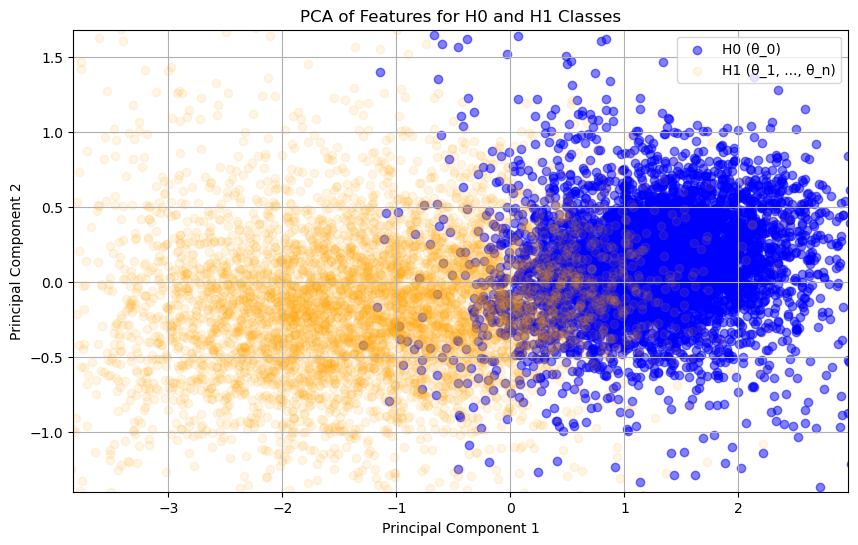

Principal Component 1: [ 0.458  0.501  0.489  0.502  0.152 -0.16 ]
Principal Component 2: [-0.302  0.167  0.185  0.183  0.101  0.896]
Principal Component 3: [-0.083 -0.053 -0.101 -0.098  0.981 -0.088]
Principal Component 4: [ 0.801 -0.266 -0.364 -0.003  0.051  0.39 ]
Explained variance ratio: [0.41067787 0.17426818 0.16106897 0.09271319]
Total explained variance: 0.8387282067


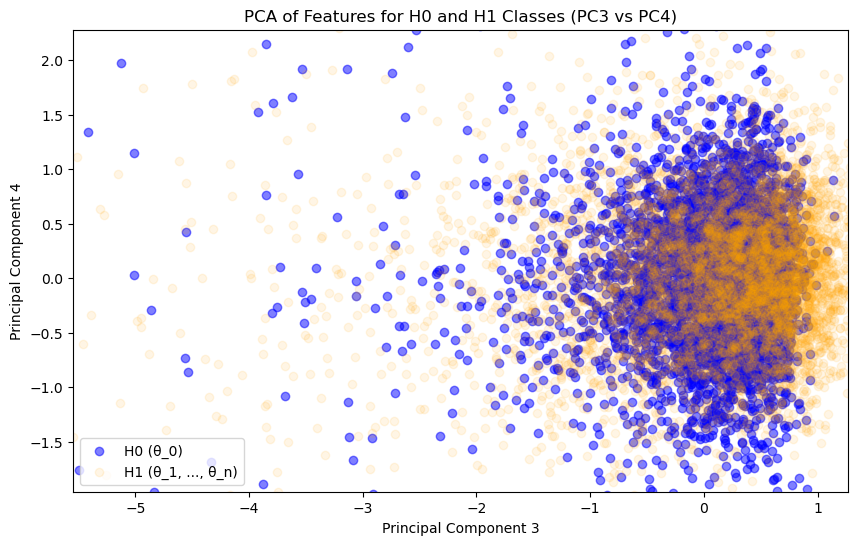

In [1069]:
#| echo: false
#| output: true

"""Make an pca of the features and plot the 2 classes"""
from sklearn.decomposition import PCA
pca = PCA(n_components=4)
std = np.std(X_features, axis=0)
mu = np.mean(X_features, axis=0)
X_features_standardization = (X_features - mu) / std
X_pca = pca.fit_transform(X_features_standardization)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[y_class == 0, 0], X_pca[y_class == 0, 1], alpha=0.5, label='H0 (θ_0)', color='blue')
plt.scatter(X_pca[y_class == 1, 0], X_pca[y_class == 1, 1], alpha=0.1, label='H1 (θ_1, ..., θ_n)', color='orange')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Features for H0 and H1 Classes')
plt.legend()
# fit the x and y limits to the data so i can see 90% of the data
dam = 99
# fit x/y limits to show the central `dam` percent of data
q_low = (100 - dam) / 2
q_high = 100 - q_low

plt.xlim(np.percentile(X_pca[:, 0], q_low), np.percentile(X_pca[:, 0], q_high))
plt.ylim(np.percentile(X_pca[:, 1], q_low), np.percentile(X_pca[:, 1], q_high))
plt.grid()
plt.show()


plt.figure(figsize=(10, 6))
plt.scatter(X_pca[y_class == 0, 2], X_pca[y_class == 0, 3], alpha=0.5, label='H0 (θ_0)', color='blue')
plt.scatter(X_pca[y_class == 1, 2], X_pca[y_class == 1, 3], alpha=0.1, label='H1 (θ_1, ..., θ_n)', color='orange')
plt.xlabel('Principal Component 3')
plt.ylabel('Principal Component 4')
plt.title('PCA of Features for H0 and H1 Classes (PC3 vs PC4)')
plt.xlim(np.percentile(X_pca[:, 2], q_low), np.percentile(X_pca[:, 2], q_high))
plt.ylim(np.percentile(X_pca[:, 3], q_low), np.percentile(X_pca[:, 3], q_high))
plt.legend()

# print pricipal components
print("Principal Component 1:", np.round(pca.components_[0], 3))
print("Principal Component 2:", np.round(pca.components_[1], 3))
print("Principal Component 3:", np.round(pca.components_[2], 3))
print("Principal Component 4:", np.round(pca.components_[3], 3))
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 10))
print("Total explained variance:", np.round(np.sum(pca.explained_variance_ratio_), 10))


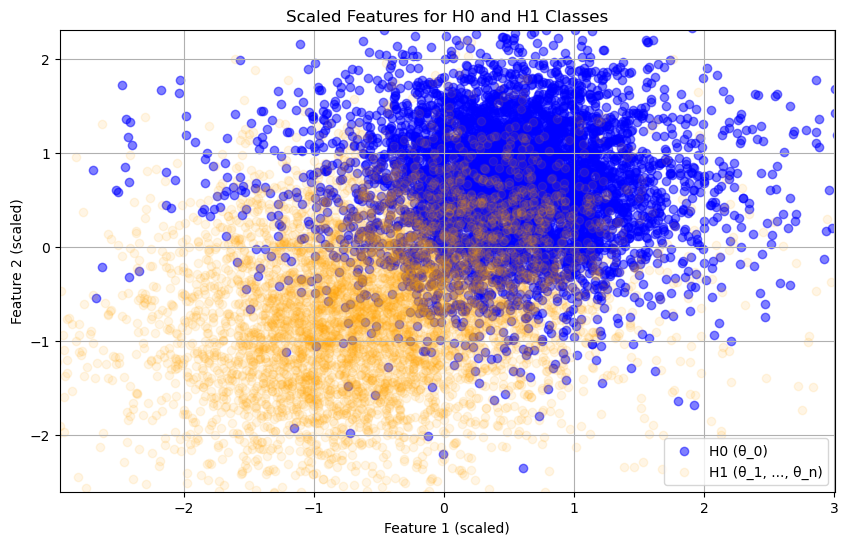

In [1070]:
#| echo: false
#| output: false

"""Normalize the features and plot the 2 classes"""
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_features)
# X_scaled = X_features
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[y_class == 0, 0], X_scaled[y_class == 0, 1], alpha=0.5, label='H0 (θ_0)', color='blue')
plt.scatter(X_scaled[y_class == 1, 0], X_scaled[y_class == 1, 1], alpha=0.1, label='H1 (θ_1, ..., θ_n)', color='orange')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.title('Scaled Features for H0 and H1 Classes')
plt.legend()
# fit the x and y limits to the data so i can see 90% of the data
dam = 99
# fit x/y limits to show the central `dam` percent of data
q_low = (100 - dam) / 2
q_high = 100 - q_low
plt.xlim(np.percentile(X_scaled[:, 0], q_low), np.percentile(X_scaled[:, 0], q_high))
plt.ylim(np.percentile(X_scaled[:, 1], q_low), np.percentile(X_scaled[:, 1], q_high))
plt.grid()
plt.show()


### Normalization

$$
X_{\text{normalized}} = \frac{X - \mu}{\sigma}
$$

Where:

- $X$: is the original feature vector.
- $\mu$: is the mean of the feature vector.
- $\sigma$: is the standard deviation of the feature vector.

In [1071]:
#| echo: false
#| output: true

# print the mean and std of each feature
print("Feature means:", np.round(np.mean(X_features, axis=0), 3))
print("Feature stds:", np.round(np.std(X_features, axis=0, dtype=np.float64), 2))

Feature means: [ 0.95   6.14  17.319 31.201  0.986  1.769]
Feature stds: [0.18 0.93 2.62 4.6  0.01 4.39]


:::

## Logistic Regression

::: panel-tabset

### Formulation

Observation vector:

$$
x = (x_1, ... , x_n)
$$

Weighted sum: ^[“8.1 Linear models” ([Herlau et al., p. 137](zotero://select/library/items/4P269CF8)) ([pdf](zotero://open-pdf/library/items/Y7FREX6H?page=151&annotation=NK6YBQP3))]

$$
z = w_1 x_1 + ... + w_n x_n + b = \sum_{i=1}^{n} w_i x_i + b
$$


Use **logistic sigmoid function** to turn it into a probability:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

Thershold:

$$
\hat{y} = \begin{cases}
1 & \text{if } \sigma(z) \geq 0.5 \\
0 & \text{if } \sigma(z) < 0.5
\end{cases}
$$

<!-- Training the Logistic Regression model: ^[“15.2 Training neural networks” ([Herlau et al., p. 255](zotero://select/library/items/4P269CF8)) ([pdf](zotero://open-pdf/library/items/Y7FREX6H?page=269&annotation=65S2NWIA))] ^[“15.3.1 Neural networks for binary classification” ([Herlau et al., p. 259](zotero://select/library/items/4P269CF8)) ([pdf](zotero://open-pdf/library/items/Y7FREX6H?page=273&annotation=UVLKNH8H))]

1. Set up maximum likelihood estimation (MLE) ^[[wiki Maximum likelihood estimation](https://en.wikipedia.org/wiki/Maximum_likelihood_estimation)]
2. 

 -->



::: {.aside}
- “8.2 Logistic Regression” ([Herlau et al., p. 143](zotero://select/library/items/4P269CF8)) ([pdf](zotero://open-pdf/library/items/Y7FREX6H?page=157&annotation=7QS54TP8)) - Intorduction to logistic regression.
:::



### Traning code


::: {.aside}
- [Standardization - scikit-learn](https://scikit-learn.org/stable/modules/preprocessing.html)
- [LogisticRegression - scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression)
:::

In [1072]:
#| echo: true
#| output: true
from sklearn.linear_model import LogisticRegression

X, y = X_train, y_train

from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit(X)
print("Feature means before scaling:", np.round(scaler.mean_, 3))
print("Feature standard deviations before scaling:", np.round(scaler.scale_, 3))

X = scaler.transform(X)

# fit a logistic regression model to the data
clf = LogisticRegression(random_state=0).fit(X, y)



Feature means before scaling: [ 0.947  6.135 17.314 31.161  0.986  1.802]
Feature standard deviations before scaling: [0.183 0.918 2.614 4.621 0.014 4.885]


### Model preformance

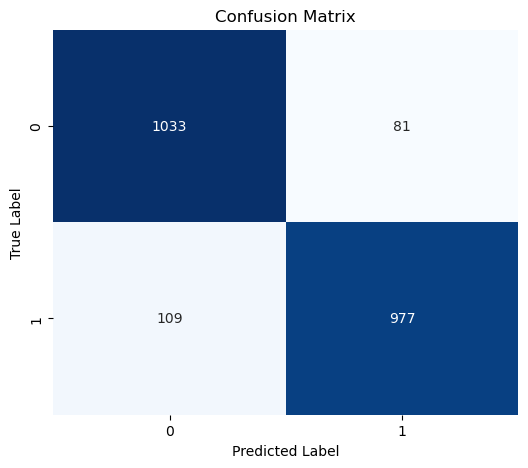

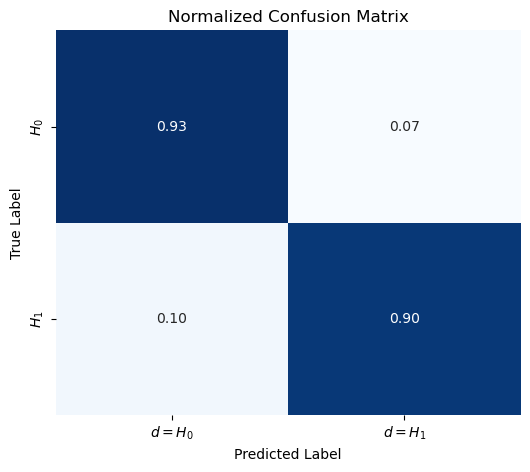

In [1073]:
#| echo: false
#| output: true
# predict the test set
# X_test_scaled = scaler.transform(X_test)
X_test_scaled = (X_test - scaler.mean_) / scaler.scale_
y_pred = clf.predict(X_test_scaled)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# plot the normalized confusion matrix
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.xticks([0.5, 1.5], [r'$d=H_0$', r'$d=H_1$'])
plt.ylabel('True Label')
plt.yticks([0.5, 1.5], [r'$H_0$', r'$H_1$'])
plt.title('Normalized Confusion Matrix')
plt.show()

In [1074]:
#| echo: false
#| output: true
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# print("\nConfusion Matrix (scaled):\n", confusion_matrix(y_test, y_pred, normalize='true'))


Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.93      0.92      1114
         1.0       0.92      0.90      0.91      1086

    accuracy                           0.91      2200
   macro avg       0.91      0.91      0.91      2200
weighted avg       0.91      0.91      0.91      2200



### Model interpretation 2D

Logistic Regression Coefficients: [[-0.987 -1.584 -1.601 -1.551 -0.639 -0.399]]
Logistic Regression Intercept: [0.785]


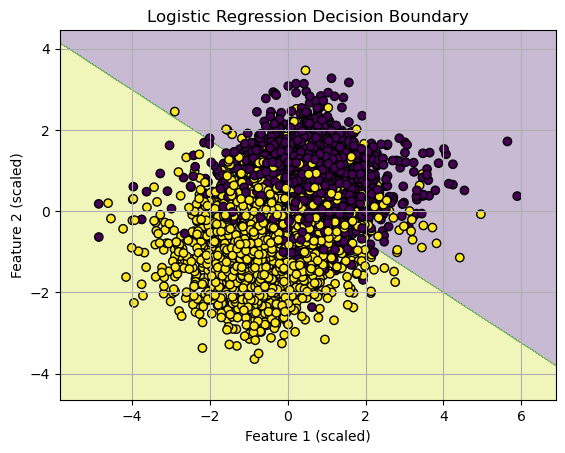

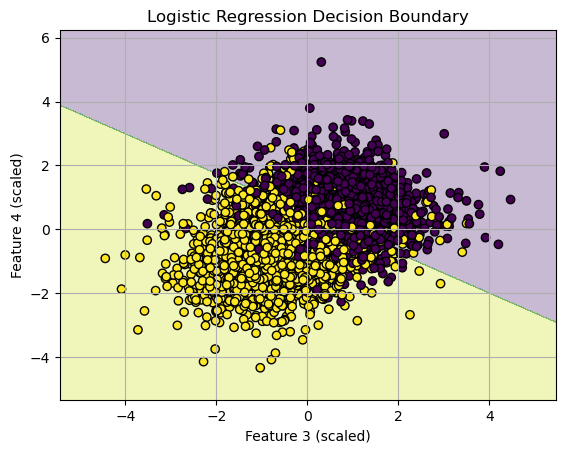

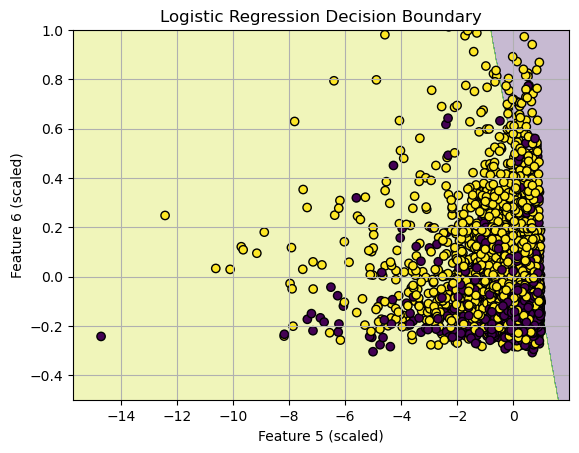

In [1075]:
#| echo: false
#| output: true
# print wights and intercept
print("Logistic Regression Coefficients:", np.round(clf.coef_, 3))
print("Logistic Regression Intercept:", np.round(clf.intercept_, 3))

# plot the 2d decision boundary for the first 2 features
def plot_decision_boundary(clf, X, y, f1=0, f2=1, xlim=None, ylim=None):
    x_min, x_max = X[:, f1].min() - 1, X[:, f1].max() + 1
    y_min, y_max = X[:, f2].min() - 1, X[:, f2].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel(), np.zeros((len(xx.ravel()), X.shape[1]-2))])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, f1], X[:, f2], c=y, edgecolors='k', marker='o')
    plt.xlabel(f'Feature {f1 + 1} (scaled)')
    plt.ylabel(f'Feature {f2 + 1} (scaled)')
    plt.title('Logistic Regression Decision Boundary')
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    plt.grid()
    plt.show()

plot_decision_boundary(clf, X, y, f1=0, f2=1)
plot_decision_boundary(clf, X, y, f1=2, f2=3)
plot_decision_boundary(clf, X, y, f1=4, f2=5, ylim=(-0.5, 1))


:::

::: {.notes}
Training the regression model: [“8.1.1 Training the linear regression model” ([Herlau et al., p. 139](zotero://select/library/items/4P269CF8)) ([pdf](zotero://open-pdf/library/items/Y7FREX6H?page=153&annotation=LAVHCF4L))] [“Eq 8.13” ([Herlau et al., p. 141](zotero://select/library/items/4P269CF8)) ([pdf](zotero://open-pdf/library/items/Y7FREX6H?page=155&annotation=J5XVKNQ9))]
$$
w^* = (X^T X)^{-1} X^T y
$$ 

- $X$: is the matrix of features for the training data.
- $y$: is the vector of target values for the training data.

Note: this is only valide for linnar regression, for logistic regression we need to use an iterative optimization algorithm, such as gradient descent.
:::

::: {.content-hidden}
### Model interpretation 3D
:::

In [1076]:
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

def plot_decision_boundary_3d_plotly(clf, X, y, f1, f2, f3):
    # Define grid
    x_min, x_max = X[:, f1].min() - 1, X[:, f1].max() + 1
    y_min, y_max = X[:, f2].min() - 1, X[:, f2].max() + 1
    z_min, z_max = X[:, f3].min() - 1, X[:, f3].max() + 1

    xx, yy, zz = np.meshgrid(
        np.linspace(x_min, x_max, 30),
        np.linspace(y_min, y_max, 30),
        np.linspace(z_min, z_max, 30)
    )

    # Build full feature grid
    grid = np.zeros((xx.size, X.shape[1]))
    grid[:, f1] = xx.ravel()
    grid[:, f2] = yy.ravel()
    grid[:, f3] = zz.ravel()

    Z = clf.predict(grid).reshape(xx.shape)

    scatter = go.Scatter3d(
        x=X[:, f1],
        y=X[:, f2],
        z=X[:, f3],
        mode='markers',
        marker=dict(size=4, color=y, colorscale='Viridis', line=dict(width=1))
    )

    surface = go.Isosurface(
        x=xx.ravel(),
        y=yy.ravel(),
        z=zz.ravel(),
        value=Z.ravel(),
        isomin=0.5,
        isomax=0.5,
        opacity=0.3,
        surface_count=1,
        showscale=False
    )

    fig = go.Figure(data=[scatter, surface])
    fig.update_layout(
        title='3D Decision Boundary',
        scene=dict(
            xaxis_title=f'Feature {f1}',
            yaxis_title=f'Feature {f2}',
            zaxis_title=f'Feature {f3}'
        )
    )

    fig.show()


# --- INTERACTIVE CONTROLS ---
n_features = X.shape[1]

f1_dropdown = widgets.Dropdown(options=list(range(n_features)), value=0, description='X-axis')
f2_dropdown = widgets.Dropdown(options=list(range(n_features)), value=1, description='Y-axis')
f3_dropdown = widgets.Dropdown(options=list(range(n_features)), value=2, description='Z-axis')

ui = widgets.VBox([f1_dropdown, f2_dropdown, f3_dropdown])

out = widgets.interactive_output(
    lambda f1, f2, f3: plot_decision_boundary_3d_plotly(clf, X, y, f1, f2, f3),
    {'f1': f1_dropdown, 'f2': f2_dropdown, 'f3': f3_dropdown}
)

display(ui, out)

Output()

## Analysis - Logistic regression

::: {.callout-note}
- this model performance is good for bad sensor configurations
- But it is not as good for good sensor configurations, why?
    - I think that it is mostly based on the traning data.
:::

In [1077]:
#| echo: true
#| output: true
from scipy.stats import multivariate_normal as mvn
from sklearn.metrics import confusion_matrix

# frequencyes and mode shapes
omega_all = load["natural_frequencies"]
phi_all = mode_shapes

# Coefficient of variation (CV)
CV_omega = 0.1
sigma_phi = 0.1

# Prior probabilities for the states (theta)
prior_theta = prior_theta

# Number of Samples 
N = 10**4

# must have an minimum of 2 sensors to be able to detect damage
e_config_2 = e_configuration[e_configuration.sum(axis=1) >= 2]


theta = OMA.theta
bayes_risk_sensors = np.zeros(len(e_config_2))
cm = np.zeros((len(e_config_2), 2, 2), dtype=int) # confusion matrix for each sensor configuration

# Instantiate the BR class
A2 = BR(omega_all, phi_all, CV_omega, sigma_phi, prior_theta, N)

# improtance sampling prior for the states (theta) H_0 = 0.5 and H_1 = 0.5
prior_H_Importance = np.array([0.5, 0.5])
prior_Importance = np.concatenate(([prior_H_Importance[0]], np.repeat(prior_H_Importance[1] / (len(prior_theta) - 1), len(prior_theta) - 1)))

print(f"Importance sampling prior probabilities for H: {prior_H_Importance}")
print(f"\nImportance sampling prior probabilities for θ: {np.round(prior_Importance, 4)}")

# print(f"e_configuration[1:]:\n {e_configuration[1:]}")
for ei, S in enumerate(e_config_2):
    # Generate samples
    A2.MCS_modal(S, prior_Importance=prior_Importance)

    A2.omega_bar
    TMAC_H0 = np.array([A2.TMAC(A2.mask_and_normalize(A2.phi_H0, S), v) for v in A2.phi_bar])
    MF = np.array([A2.MF(phi, omega) for phi, omega in zip(A2.phi_bar, A2.omega_bar)])

    # y_class_temp = np.array(A2.H_vec)  # true class labels (0 for H0, 1 for H1)
    X_features = np.column_stack((A2.omega_bar, TMAC_H0, MF))

    # d_vec = (Post1 > Post0).astype(int)
    X_test_scaled = (X_features  - scaler.mean_) / scaler.scale_
    d_vec = clf.predict(X_test_scaled)

    # Loss and Bayes Risk
    total_costs = prediction_cost[A2.H_vec, np.array(d_vec).astype(int)] + sensor_cost(len(e_config_2[sum(S)]))

    # Confusion matrix
    cm[ei] = confusion_matrix(A2.H_vec, d_vec)

    # Importance weights for the samples
    w = prior_H/prior_H_Importance
    importance_weights = w[A2.H_vec]  # Get the importance weights for each sample based on its true state H_vec


    # Estimation of the bayes risk using Monte Carlo.
    Bayes_Risk = np.mean(importance_weights * total_costs)

    print(f"Bayes Risk: {Bayes_Risk}")
    bayes_risk_sensors[ei] = Bayes_Risk


Importance sampling prior probabilities for H: [0.5 0.5]

Importance sampling prior probabilities for θ: [0.5    0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333
 0.0333 0.0333 0.0333 0.0333 0.0333 0.0333]
Bayes Risk: 29.130507999999995
Bayes Risk: 27.343752000000002
Bayes Risk: 22.956972
Bayes Risk: 20.93484
Bayes Risk: 25.122072
Bayes Risk: 25.169428
Bayes Risk: 21.5434
Bayes Risk: 28.200376000000002
Bayes Risk: 20.380892000000003
Bayes Risk: 19.34818
Bayes Risk: 18.221691999999997


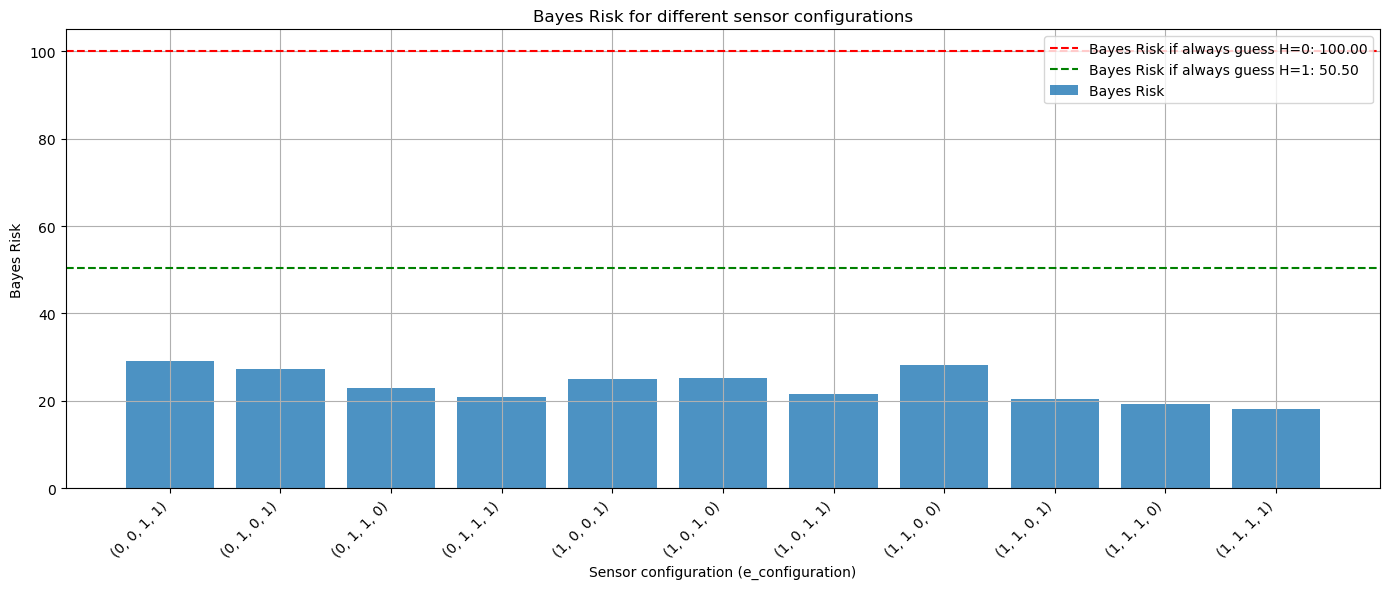

Minimum Bayes Risk: 18.221691999999997
Best sensor configuration: [1 1 1 1] (index: 10)


In [1078]:
#| output: True
# bayes_risk_sensors = bayes_risk_sensors - [sensor_cost(len(e_configuration[i])) for i in range(len(e_configuration))]
x = np.arange(len(e_config_2))  # x-axis values for the bar plot
labels = [str(tuple(int(n) for n in cfg)) for cfg in e_config_2]
plt.figure(figsize=(14, 6))
plt.bar(x, bayes_risk_sensors, width=0.8, label="Bayes Risk", alpha=0.8)
# print the bayes risk for each ther always guses H=0 and H=1
BR_H0 = prediction_cost[0, 0] * prior_H[0] + prediction_cost[1, 0] * prior_H[1]
BR_H1 = prediction_cost[0, 1] * prior_H[0] + prediction_cost[1, 1] * prior_H[1]
plt.axhline(BR_H0, color='red', linestyle='--', label=f"Bayes Risk if always guess H=0: {BR_H0:.2f}")
plt.axhline(BR_H1, color='green', linestyle='--', label=f"Bayes Risk if always guess H=1: {BR_H1:.2f}")

plt.xlabel("Sensor configuration (e_configuration)")
plt.ylabel("Bayes Risk")
plt.title("Bayes Risk for different sensor configurations")
plt.xticks(x, labels, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# min bayes risk
min_bayes_risk = np.min(bayes_risk_sensors)
best_config_index = np.argmin(bayes_risk_sensors)
best_config = e_config_2[best_config_index]
print(f"Minimum Bayes Risk: {min_bayes_risk}")
print(f"Best sensor configuration: {best_config} (index: {best_config_index})")

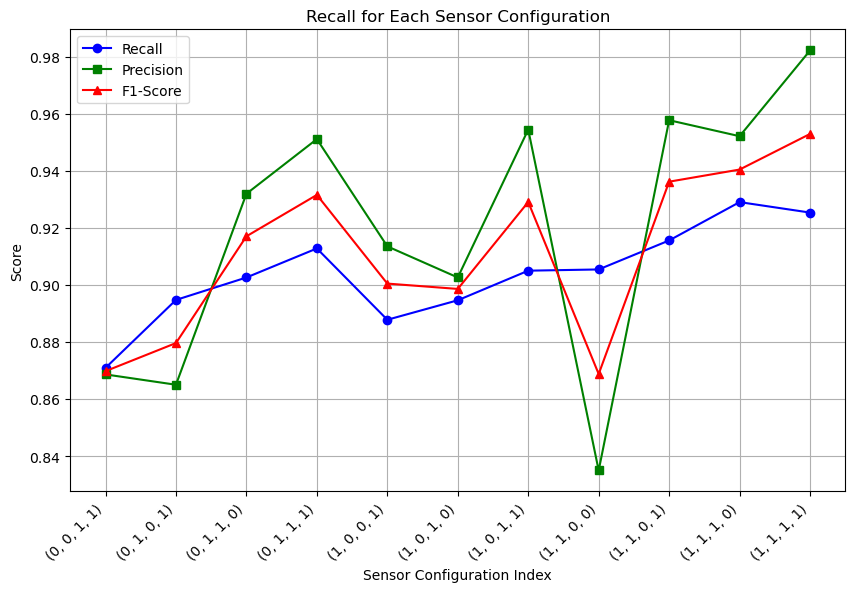

In [1079]:
#| output: true
# plot recall for each sensor configuration
recall = cm[:, 1, 1] / (cm[:, 1, 1] + cm[:, 1, 0] )  # TP / (TP + FN)
precision = cm[:, 1, 1] / (cm[:, 1, 1] + cm[:, 0, 1] ) # TP / (TP + FP)
F1_score = 2 * (precision * recall) / (precision + recall)

x = np.arange(1, len(e_config_2) + 1)  # 1..15 (matches recall length)
labels = [str(tuple(int(n) for n in cfg)) for cfg in e_config_2]  # 15 labels

plt.figure(figsize=(10, 6))
plt.plot(x, recall, marker='o', label='Recall', color='blue')
plt.plot(x, precision, marker='s', label='Precision', color='green')
plt.plot(x, F1_score, marker='^', label='F1-Score', color='red')
plt.xlabel('Sensor Configuration Index')
plt.ylabel('Score')
plt.title('Recall for Each Sensor Configuration')
plt.xticks(x, labels, rotation=45, ha="right")
plt.grid()
plt.legend()
plt.show()

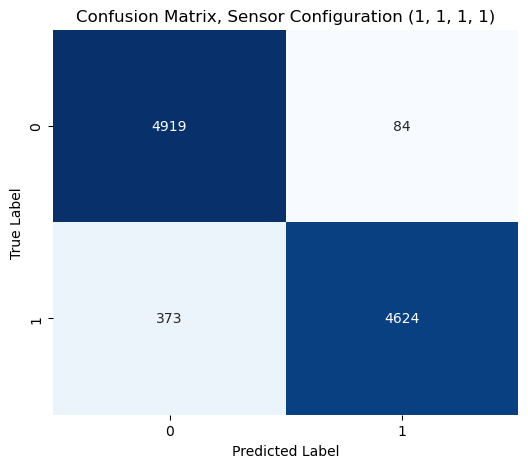

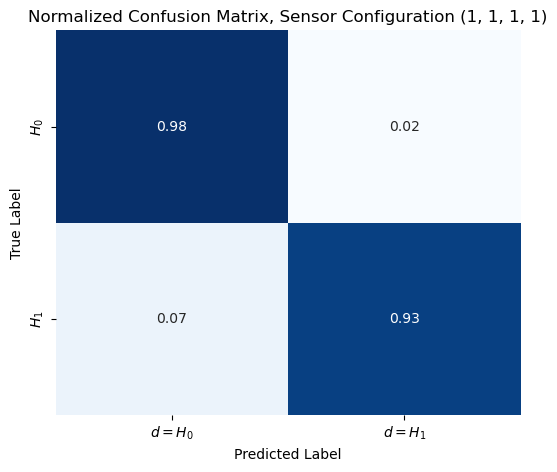

In [1080]:
#| output: true
import seaborn as sns
# Use the best sensor configuration
best_S = best_config
y_test_best = A1.H_vec  # True labels from the last MCS run
y_pred_best = d_vec     # Predictions from the last MCS run

# Plot the confusion matrix
# cm_best = confusion_matrix(y_test_best, y_pred_best)
cm_best = cm[-1]
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix, Sensor Configuration {tuple(map(int, best_S))}')
plt.show()

# Plot the normalized confusion matrix
# cm_best_normalized = confusion_matrix(y_test_best, y_pred_best, normalize='true')
cm_best_normalized = cm[-1] / cm[-1].sum(axis=1, keepdims=True)  # Normalize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_normalized, annot=True, fmt='.2f', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.xticks([0.5, 1.5], [r'$d=H_0$', r'$d=H_1$'])
plt.ylabel('True Label')
plt.yticks([0.5, 1.5], [r'$H_0$', r'$H_1$'])
plt.title(f'Normalized Confusion Matrix, Sensor Configuration {tuple(map(int, best_S))}')
plt.show()


# Questions ? 

## Error In OMA? 

::: panel-tabset
### Question

What is ralistic values of variaction in the error in OMA?  

- frequensy
- mode shapes

::: {.notes}
- Show waht it means whit out reduction form sensors? 
- best sensor configuration maximum minimization in sensor error
- but also show mean? 
:::

### Code illustration $\frac{1}{\|\mathbf S(e) \odot \phi_i\|_2^{(\star)}}$

::: {.callout-note}
- $\phi$ is assumed to be uniform, between -1 and 1
- $\phi$ is normilized, so it has at least one value of 1 or -1.
- $\phi$ is there for in this cass somewhat dependent on the lengh of the mode shape vector.
:::


C:\Users\axiom\AppData\Local\Temp\ipykernel_23692\1338305672.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  y[_, i] += 1/(np.linalg.norm(np.multiply(S, phi[_]))**2)


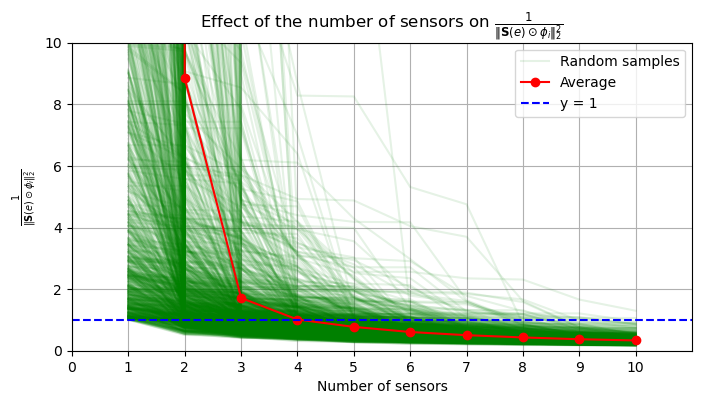

Mean values of |phi|: 0.498689392669938
Number of samples: 1000


In [1081]:
#| output: true
number_of_sensors = 10
number_of_samples = 1000
number_of_sensors += 1 # to include the case with 0 sensors
y = np.zeros((number_of_samples, number_of_sensors)) 
phi = np.random.uniform(-1, 1, (number_of_samples, number_of_sensors))
phi = phi / np.max(np.abs(phi))
plt.figure(figsize=(8, 4))
for _ in range(number_of_samples):
    # print(f"phi: {np.round(phi, 2)}") 
    for i in range(number_of_sensors):
        S = np.zeros(number_of_sensors); S[:i] = 1
        y[_, i] += 1/(np.linalg.norm(np.multiply(S, phi[_]))**2)
    plt.plot(range(number_of_sensors), y[_], alpha=0.1, color='green', label='Random samples' if _ == 0 else "")
    # if y[_][1] < 0: # only plot the first 100 samples to avoid clutter
        #  plt.plot(range(number_of_sensors), y[_], alpha=0.1, color='green', label='Random samples' if _ == 0 else "")

plt.plot(range(number_of_sensors), np.mean(y, axis=0), marker='o', color='red', label='Average')

def fun(x):
    x = np.asarray(x)
    # out = np.zeros_like(x, dtype=float)
    # for i in range(len(x)):
    #     out[i] = np.sqrt(sum(0.58**2 for j in range(i)))**2
    out = 1/(0.58**2 * x)
    return out

# plt.plot(range(number_of_sensors), fun(range(number_of_sensors)), color='blue', label=r'$\text{Number of sensors} \cdot 0.58^2$') 


plt.xlabel('Number of sensors')
plt.ylabel(r'$\frac{1}{\|\mathbf{S}(e)\odot\phi_i\|_2^2}$')
plt.title(r'Effect of the number of sensors on $\frac{1}{\|\mathbf{S}(e)\odot\phi_i\|_2^2}$')
plt.axhline(1, color='blue', linestyle='--', label='y = 1')
# show all the numbers on the x-axis
plt.xticks(range(number_of_sensors))
plt.legend()
plt.ylim(0,10)
plt.xlim(0, number_of_sensors)
plt.grid()
plt.show()

print(f"Mean values of |phi|: {np.abs(phi).mean(axis=0).mean()}")
print(f"Number of samples: {number_of_samples}")

C:\Users\axiom\AppData\Local\Temp\ipykernel_23692\989656314.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  y[_, i] += 1/(np.linalg.norm(np.multiply(S, phi[_])))


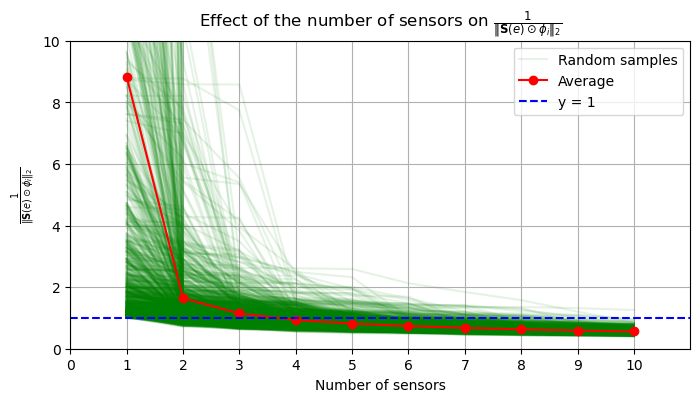

Mean values of |phi|: 0.5073268141520177
Number of samples: 1000


In [1082]:
#| output: true
number_of_sensors = 10
number_of_samples = 1000
number_of_sensors += 1 # to include the case with 0 sensors
y = np.zeros((number_of_samples, number_of_sensors)) 
phi = np.random.uniform(-1, 1, (number_of_samples, number_of_sensors))
phi = phi / np.max(np.abs(phi))
plt.figure(figsize=(8, 4))
for _ in range(number_of_samples):
    # print(f"phi: {np.round(phi, 2)}") 
    for i in range(number_of_sensors):
        S = np.zeros(number_of_sensors); S[:i] = 1
        y[_, i] += 1/(np.linalg.norm(np.multiply(S, phi[_])))
    plt.plot(range(number_of_sensors), y[_], alpha=0.1, color='green', label='Random samples' if _ == 0 else "")
    # if y[_][1] < 0: # only plot the first 100 samples to avoid clutter
        #  plt.plot(range(number_of_sensors), y[_], alpha=0.1, color='green', label='Random samples' if _ == 0 else "")

plt.plot(range(number_of_sensors), np.mean(y, axis=0), marker='o', color='red', label='Average')

def fun(x):
    x = np.asarray(x)
    # out = np.zeros_like(x, dtype=float)
    # for i in range(len(x)):
    #     out[i] = np.sqrt(sum(0.58**2 for j in range(i)))**2
    out = 1/(0.58**2 * x)
    return out

# plt.plot(range(number_of_sensors), fun(range(number_of_sensors)), color='blue', label=r'$\text{Number of sensors} \cdot 0.58^2$') 


plt.xlabel('Number of sensors')
plt.ylabel(r'$\frac{1}{\|\mathbf{S}(e)\odot\phi_i\|_2}$')
plt.title(r'Effect of the number of sensors on $\frac{1}{\|\mathbf{S}(e)\odot\phi_i\|_2}$')
# plot horizontal line at y=1 to show the case where the number of sensors is large enough to capture all the modes
plt.axhline(1, color='blue', linestyle='--', label='y = 1')
# show all the numbers on the x-axis
plt.xticks(range(number_of_sensors))
plt.legend()
plt.ylim(0,10)
plt.xlim(0, number_of_sensors)
plt.grid()
plt.show()

print(f"Mean values of |phi|: {np.abs(phi).mean(axis=0).mean()}")
print(f"Number of samples: {number_of_samples}")


In [1083]:
#| output: true
print(f"Mode shapes 0:\n{np.round(phi_all[0], 3)}")
print(f"\nSum of the absolute values of the first mode shape across all samples: \n{np.abs(phi_all[0]).sum( axis=0)}")
print(f"\nMean of the absolute values of the first mode shape across all samples: \n{np.abs(phi_all[0]).mean( axis=0)}")


Mode shapes 0:
[[ 0.093  0.328  0.647  1.   ]
 [ 0.505  1.     0.544 -0.726]
 [ 1.     0.335 -0.972  0.427]
 [ 1.    -0.968  0.617 -0.174]]

Sum of the absolute values of the first mode shape across all samples: 
[2.59767468 2.63070467 2.78064049 2.32723371]

Mean of the absolute values of the first mode shape across all samples: 
[0.64941867 0.65767617 0.69516012 0.58180843]


:::

## damage and material properties

::: {.callout-caution title="Question ?"}
- How does damage affect the material properties of the structure?
- How does damage affect the probability of structural failure?
:::

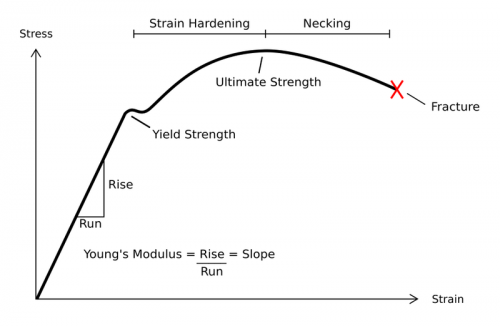

::: {.notes}
- stress in to plastic range, moves elsatic zone
:::

:::

## damage level? 

::: panel-tabset

### Question


::: {.callout-caution title="Question ?"}
What damage level do my model need to be able to detect?
:::  



::: {.callout-tip title="Idear 1"}
- Introduce probaility of failure function
- Introduce probability of stiffness change function
:::


::: {.notes}
- What is the damage level that the model need to be able to detect?
:::

### Idear 1

<!-- ::: {.callout-caution title="Assumptions / statements"}
- The building always have an probability of failure, even given no damage
- the probability of failure increases with the damage level
- the probability of failure is a function of the stiffness change, which is a function of the damage level
::: -->

Probability of failure given the damage level and the structural state:

$$
P(\text{failure} \mid \Delta E, \theta) , \text{  continuous function}
$$

Probability of stiffness change given structural states:
$$
P(\Delta E \mid H) , \text{  continuous function}
$$

What will we use them for? 

- Update the cost matrix, so that the cost of a false negative is given as the probability of failure times the expected cost of failure

::: {.callout-caution title="Assumptions / statements"}
- The estimation of thes probalistic function requires an separate simulation study.
  - make assumptions about the functions ? 
:::

Reformulation of model to continuous damage levels:

- Gives no significant changes in the logistic regression model, only in how the data is generated? 
- change the formulation of the likelihood function. (Need to think) 

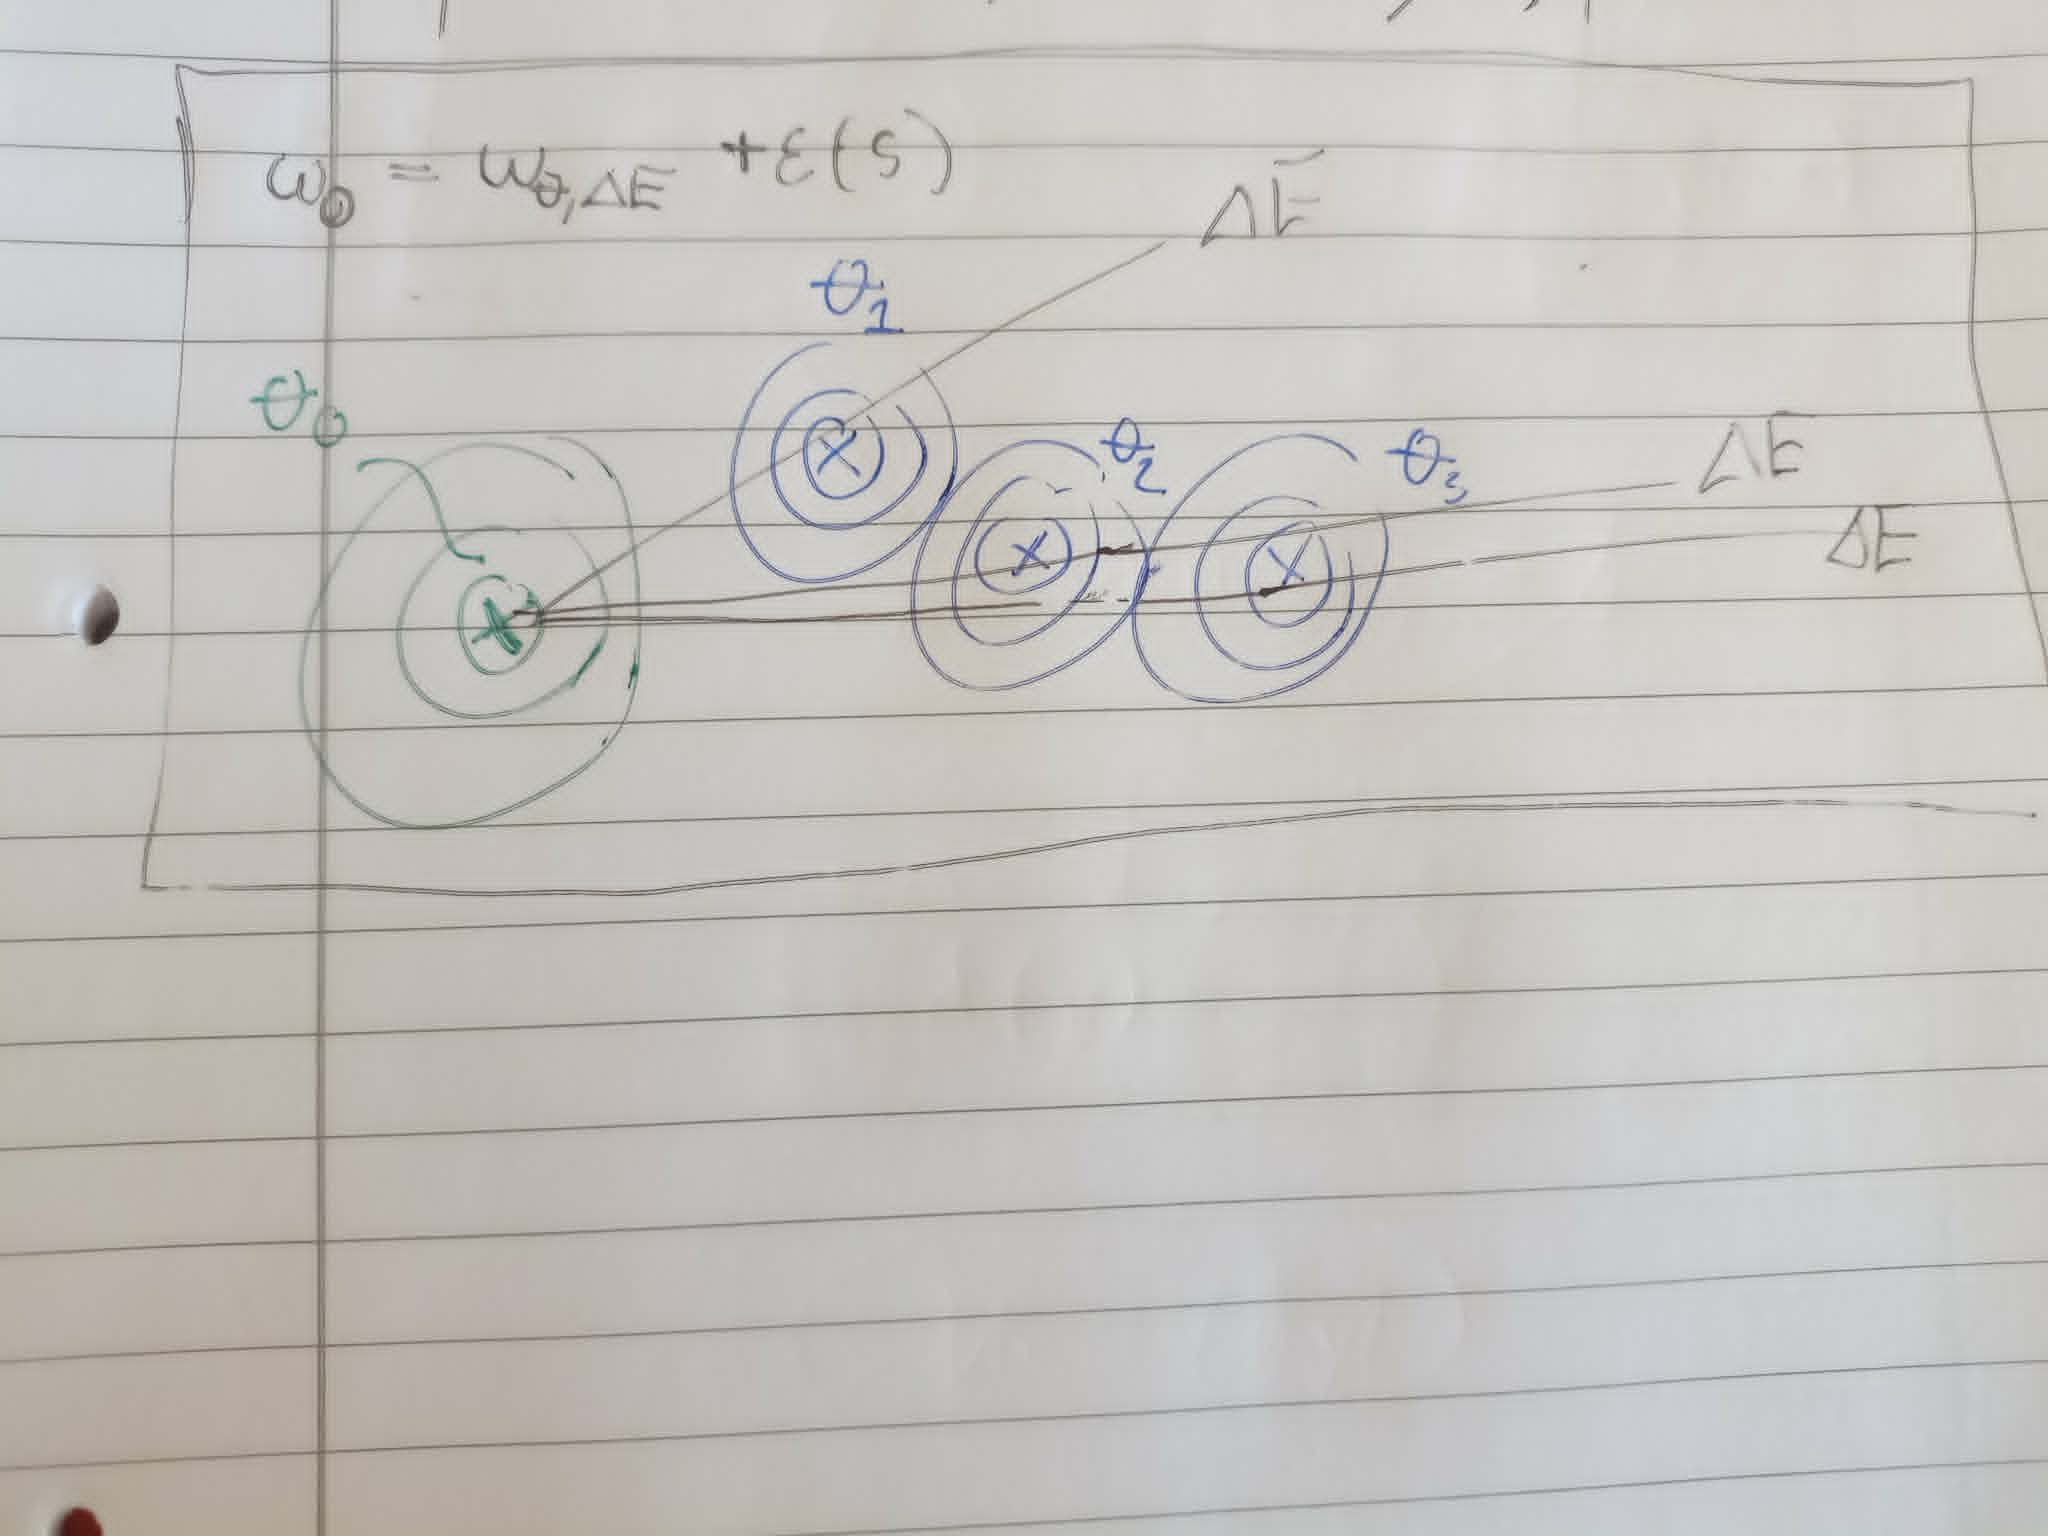

::: {.notes}
- The building always have an probability of failure, even given no damage
- the probability of failure increases with the damage level
- the probability of failure is a function of the stiffness change, which is a function of the damage level
:::

:::

# Whats next?

## My next work suggestions

::: panel-tabset

### Week overview

- Week +1: Work on model capability.
- Week +2: Bigger FEM model + more realistic Priors and cost functions.

### Model capability

.

### Model realism  

- 3 structural casse studies
    - Hospital building (hige cost of FN)
    - ~ (hige cost of FP)
    - Low cost of both FN but high relative cost of FP
- bigge FEM model


:::

::: {.content-hidden}
# Running the document 
:::

In [ ]:
#| echo: false
#| output: false
#-- åben pdf
import os
def open_pdf(file_path):
    try:
        os.startfile(file_path)
        print("PDF-filen er åbnet.")
    except Exception as e:
        print(f"Der opstod en fejl: {e}")
def close_adobe_acrobat():
    os.system("taskkill /f /im Acrobat.exe")  # Luk Adobe Acrobat Reader
#-- hent filnaven
from IPython import get_ipython
ip = get_ipython()
path = None
if '__vsc_ipynb_file__' in ip.user_ns:
    path = ip.user_ns['__vsc_ipynb_file__']
notebook_name = os.path.splitext(os.path.basename(path))[0]
#-- test count
countPDF = 0; countHTML = 0;countGitHub = 0
# countPDF = 0; countHTML = 1;countGitHub = 0
# countPDF = 0; countHTML = 1;countGitHub = 1

In [1085]:
#| echo: false
#| output: false
# countPDF += 1
# if countPDF > 1: #!quarto render notebook_name.ipynb --to pdf
#   os.system(f"quarto render {notebook_name}.ipynb --to beamer")
#   #open_pdf(f"{notebook_name}.pdf")
#   os.system(f"start {notebook_name}.pdf")

In [1089]:
#| echo: false
#| output: false
# quarto render P_new.ipynb --to revealjs --output P_new.html
countHTML += 1
if countHTML > 1: #!quarto render notebook_name.ipynb --to html
  os.system(f"quarto render {notebook_name}.ipynb --to revealjs --output {notebook_name}.html")
  os.system(f"start {notebook_name}.html")

In [1091]:
#| echo: false 
#| output: false
# save an copy notebook_name.html in the "research-notebook" folder and rename it "index.html"ArithmeticError
countGitHub += 1
if countGitHub > 1:
  from quarto_files.git_add import git_add_and_push
  # add index.html to git and push to GitHub
  git_add_and_push(notebook_name, output_name="P_new",  type="html")
  # add Readme.md to git and push to GitHub
#   git_add_and_push("Readme", type="md")
  


Current directory: c:\Users\axiom\OneDrive - Danmarks Tekniske Universitet\5. kandidat - Semester
✅ Source file exists: P_new.html
File size: 15027401 bytes
✅ Destination directory exists: research-notebook
Files in destination: ['.git', 'index.html', 'P_new.html', 'README.md', 'Theory Of The Model.md', 'week_16', 'week_17']
Copy command output:         1 file(s) copied.

Copy command errors: 
Copy command return code: 0
✅ File successfully copied to research-notebook\P_new.html

Changed to directory: c:\Users\axiom\OneDrive - Danmarks Tekniske Universitet\5. kandidat - Semester\research-notebook
❌ Git operation failed: [WinError 2] The system cannot find the file specified

Returned to: c:\Users\axiom\OneDrive - Danmarks Tekniske Universitet\5. kandidat - Semester
